# Estimación de Flujo Vertical en la Interfaz Río-Acuífero mediante Trazadores Térmicos

## Análisis de Datos de Terreno — Implementación Python de VFLUX2

### Descripción del estudio
Este notebook implementa el procesamiento de datos reales de temperatura medidos en el lecho de un río para estimar 
el flujo vertical de agua subterránea ($q_z$) en la zona hiporreica, utilizando **cinco métodos analíticos** 
basados en la propagación de señales térmicas diurnas (Hatch et al., 2006; Keery et al., 2007; McCallum et al., 2012; Luce et al., 2013).

### Instrumentación
| Parámetro | Valor |
|-----------|-------|
| **Sensores** | iButton DS1922L / DS1923 (Maxim Integrated) |
| **Resolución** | 0.0625 °C (DS1922L), 0.5 °C (DS1923) |
| **Frecuencia de muestreo** | 30 min (Δt = 1800 s) |
| **Periodo de registro** | 20 Dic 2025 – 22 Ene 2026 (~33 días) |
| **Configuración** | 3 termocuplas (TC1, TC3, TC5), 3 sensores cada una (9 total) |
| **Profundidades** | TC1/TC5: 0.00, 0.28, 0.56 m; TC3: 0.00, 0.20, 0.40 m (mbnt) |

### Fundamento teórico
La señal de temperatura diurna en un medio poroso saturado se atenúa exponencialmente y se desfasa con la profundidad.
La ecuación de transporte advectivo-conductivo de calor 1D en estado cuasi-estacionario es:

$$\frac{\partial T}{\partial t} = \kappa_e \frac{\partial^2 T}{\partial z^2} - \frac{q_z \rho_w c_w}{\rho c} \frac{\partial T}{\partial z}$$

donde $\kappa_e$ es la difusividad térmica efectiva, $q_z$ el flujo de Darcy vertical, y $\rho_w c_w$, $\rho c$ son las capacidades caloríficas volumétricas del agua y del sedimento saturado, respectivamente.

### Pipeline de procesamiento
1. **Carga de datos** — Lectura de archivos CSV iButton exportados desde OneWireViewer
2. **Mapeo de sensores** — Asignación verificada de cada sensor a su termocupla y profundidad
3. **Control de calidad** — Detección de outliers y artefactos de extracción
4. **Alineación temporal** — Remuestreo a grilla regular de 30 min
5. **Análisis armónico** — Ajuste sinusoidal para extraer amplitud ($A$) y fase ($\phi$) del ciclo diario
6. **Estimación de flujo** — Aplicación de 5 métodos VFLUX2 (McCallum, Hatch-A, Hatch-φ, Keery, Luce)
7. **Análisis de resultados** — Comparación entre métodos y termocuplas

In [1]:
# ============================================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Configuración de gráficos - estilo publicación
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
})

# Paths del proyecto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Importar módulos vfluxx
from vfluxx.io_utils import load_all_ibuttons, ibuttons_to_dataframe
from vfluxx.preprocess import align_and_resample
from vfluxx.harmonic_analysis import fit_harmonic_model, analyze_sensor_pair
from vfluxx.vflux_methods import calculate_vflux_all_methods

# Directorios de salida
img_dir = project_root / 'image'
out_dir = project_root / 'resultados_python' / 'datos_terreno'
out_dir.mkdir(parents=True, exist_ok=True)

print("[OK] Entorno configurado correctamente")
print(f"  Proyecto: {project_root.name}")
print(f"  Salida imagenes: {img_dir.relative_to(project_root)}/")
print(f"  Salida datos:    {out_dir.relative_to(project_root)}/")

[OK] Entorno configurado correctamente
  Proyecto: Hidrologia-Termocuplas-BH
  Salida imagenes: image/
  Salida datos:    resultados_python\datos_terreno/


---
## 2. Carga y Exploración de Datos

Los sensores iButton DS1922L y DS1923 almacenan registros de temperatura en formato CSV con metadatos de cabecera.
Se cargan los 6 archivos del directorio `data/raw/Datos_Terreno/`.

In [2]:
# === CELDA 2: Cargar todos los archivos iButton ===
data_dir = project_root / 'data' / 'raw' / 'Datos_Terreno'
sensors = load_all_ibuttons(data_dir)

print(f"\nResumen de sensores cargados:")
print(f"{'#':<4} {'ID Sensor':<22} {'Tipo':<10} {'Registros':<10} {'Inicio':<12} {'Fin':<12} {'T min':<8} {'T max':<8}")
print("-" * 90)
for i, s in enumerate(sensors):
    df_s = s['df']
    print(f"{i+1:<4} {s['sensor_id'][:20]:<22} {s['part_number']:<10} {len(df_s):<10} "
        f"{df_s['datetime'].min().strftime('%Y-%m-%d'):<12} {df_s['datetime'].max().strftime('%Y-%m-%d'):<12} "
        f"{df_s['temperature'].min():<8.1f} {df_s['temperature'].max():<8.1f}")

Cargando 9 archivos iButton desde Datos_Terreno/
  ✔ 2800000082978041_012226.csv: DS1922L | 1601 registros | 2025-12-20 → 2026-01-22 | T: [16.4, 25.3] °C
  ✔ 2D00000082925E41_012226.csv: DS1922L | 1635 registros | 2025-12-19 → 2026-01-22 | T: [12.9, 32.6] °C
  ✔ 3800000082952A41_012226.csv: DS1922L | 1591 registros | 2025-12-20 → 2026-01-22 | T: [14.2, 22.9] °C
  ✔ 5900000082B86A41_012226.csv: DS1923 | 1679 registros | 2025-12-18 → 2026-01-22 | T: [16.5, 35.4] °C
  ✔ 7D000000828FA841_012226.csv: DS1922L | 1678 registros | 2025-12-18 → 2026-01-22 | T: [14.7, 36.5] °C
  ✔ A400000082BAF041_012226.csv: DS1923 | 1678 registros | 2025-12-18 → 2026-01-22 | T: [13.1, 36.4] °C
  ✔ B000000082987741_012226.csv: DS1922L | 1601 registros | 2025-12-20 → 2026-01-22 | T: [16.4, 23.7] °C
  ✔ B3000000828F2741_012226.csv: DS1922L | 1635 registros | 2025-12-19 → 2026-01-22 | T: [13.1, 33.2] °C
  ✔ F60000008290D841_012226.csv: DS1922L | 1635 registros | 2025-12-19 → 2026-01-22 | T: [12.8, 34.4] °C
Sensores

---
## 3. Mapeo de Sensores a Termocuplas y Profundidades

> **Nomenclatura TC1 / TC3 / TC5**: En la campaña de terreno se instalaron 5 termocuplas numeradas del 1 al 5. 
> Se equiparon **TC1, TC3 y TC5** con 3 sensores iButton cada una para el perfil vertical completo.
> Las termocuplas TC2 y TC4 se reservaron para otras mediciones y no cuentan con datos de temperatura.

El mapeo fue verificado comparando los rangos de temperatura de cada sensor con las series generadas 
por el software **MATLAB VFLUX2** y el script `procesar_datos_terreno.py`.

**Criterio de asignación**: la amplitud térmica diurna disminuye monotónicamente con la profundidad 
en un medio poroso saturado. El sensor superficial presenta la mayor amplitud y el profundo la menor.

### Configuración de Sensores por Termocupla

| Termocupla | Posición | Profundidad (mbnt) | Sensor ID | Coordenadas UTM (19S) |
|:----------:|:--------:|:------------------:|:---------:|:---------------------:|
| **TC1** | Superficie | 0.00 | A400000082BAF041 | 347285 E, 6473381 N |
| **TC1** | Intermedio | 0.28 | 7D000000828FA841 | — |
| **TC1** | Inferior | 0.56 | 5900000082B86A41 | — |
| **TC3** | Superficie | 0.00 | F60000008290D841 | 347087 E, 6472284 N |
| **TC3** | Intermedio | 0.20 | 2D00000082925E41 | — |
| **TC3** | Inferior | 0.40 | B3000000828F2741 | — |
| **TC5** | Superficie | 0.00 | 3800000082952A41 | 346618 E, 6471135 N |
| **TC5** | Intermedio | 0.28 | B000000082987741 | — |
| **TC5** | Inferior | 0.56 | 2800000082978041 | — |

> **Nota**: TC3 tiene profundidades diferentes (0.00, 0.20, 0.40 m) debido a condiciones del lecho.

In [3]:
# ============================================================================
# === CELDA 3: CONFIGURACIÓN MAESTRA DE SENSORES Y PROFUNDIDADES ===
# ============================================================================
# Fuente: scripts/procesar_datos_terreno.py (configuración oficial verificada)
# 9 sensores iButton en 3 termocuplas (TC1, TC3, TC5) con perfiles verticales

# Los sensores se cargan en orden alfabético por nombre de archivo.
# Orden resultante: 28..., 2D..., 38..., 59..., 7D..., A4..., B0..., B3..., F6...
#   temp_1 = 2800000082978041 → TC5 inferior   (0.56 m)
#   temp_2 = 2D00000082925E41 → TC3 intermedio (0.20 m)
#   temp_3 = 3800000082952A41 → TC5 superficie (0.00 m)
#   temp_4 = 5900000082B86A41 → TC1 inferior   (0.56 m)
#   temp_5 = 7D000000828FA841 → TC1 intermedio (0.28 m)
#   temp_6 = A400000082BAF041 → TC1 superficie (0.00 m)
#   temp_7 = B000000082987741 → TC5 intermedio (0.28 m)
#   temp_8 = B3000000828F2741 → TC3 inferior   (0.40 m)
#   temp_9 = F60000008290D841 → TC3 superficie (0.00 m)

sensor_labels = [f'temp_{i+1}' for i in range(len(sensors))]

# ============================================================================
# MAPEO VERIFICADO: SENSOR ID → TERMOCUPLA → POSICIÓN → PROFUNDIDAD
# Coordenadas UTM Zona 19S (EPSG:32719)
# ============================================================================

# TC1 (Termocupla 1) - Estación superior del perfil
tc1 = {
    'surface':      'temp_6',  # A400000082BAF041 → 0.00 m
    'intermediate': 'temp_5',  # 7D000000828FA841 → 0.28 m
    'deep':         'temp_4',  # 5900000082B86A41 → 0.56 m
}

# TC3 (Termocupla 3) - Estación media del perfil (profundidades diferentes)
tc3 = {
    'surface':      'temp_9',  # F60000008290D841 → 0.00 m
    'intermediate': 'temp_2',  # 2D00000082925E41 → 0.20 m
    'deep':         'temp_8',  # B3000000828F2741 → 0.40 m
}

# TC5 (Termocupla 5) - Estación inferior del perfil
tc5 = {
    'surface':      'temp_3',  # 3800000082952A41 → 0.00 m
    'intermediate': 'temp_7',  # B000000082987741 → 0.28 m
    'deep':         'temp_1',  # 2800000082978041 → 0.56 m
}

# Configuración completa de TODAS las termocuplas
TC_CONFIG = {
    'TC1': tc1,
    'TC3': tc3,
    'TC5': tc5,
}

# Profundidades en metros bajo nivel de terreno (mbnt)
depths_m = {
    # TC1
    'temp_6': 0.00,  # TC1 superficie
    'temp_5': 0.28,  # TC1 intermedio
    'temp_4': 0.56,  # TC1 inferior
    # TC3 (perfiles diferentes)
    'temp_9': 0.00,  # TC3 superficie
    'temp_2': 0.20,  # TC3 intermedio
    'temp_8': 0.40,  # TC3 inferior
    # TC5
    'temp_3': 0.00,  # TC5 superficie
    'temp_7': 0.28,  # TC5 intermedio
    'temp_1': 0.56,  # TC5 inferior
}

# Asignación de termocupla por sensor
tc_assignment = {
    # TC1
    'temp_4': 'TC1', 'temp_5': 'TC1', 'temp_6': 'TC1',
    # TC3
    'temp_2': 'TC3', 'temp_8': 'TC3', 'temp_9': 'TC3',
    # TC5
    'temp_1': 'TC5', 'temp_3': 'TC5', 'temp_7': 'TC5',
}

# Coordenadas UTM exactas (EPSG:32719 - UTM Zona 19S)
STATION_COORDS_UTM = {
    "TC1": {"easting": 347285, "northing": 6473381},
    "TC2": {"easting": 347440, "northing": 6473566},  # Sin datos, solo posición
    "TC3": {"easting": 347087, "northing": 6472284},
    "TC4": {"easting": 347113, "northing": 6472121},  # Sin datos, solo posición
    "TC5": {"easting": 346618, "northing": 6471135},
}

# Termocuplas con datos activos
ACTIVE_TCS = ["TC1", "TC3", "TC5"]

# Paleta de colores por termocupla
TC_COLORS = {
    "TC1": {"base": "#1f77b4", "surface": "#1f77b4", "intermediate": "#ff7f0e", "deep": "#2ca02c"},
    "TC3": {"base": "#e377c2", "surface": "#e377c2", "intermediate": "#7f7f7f", "deep": "#bcbd22"},
    "TC5": {"base": "#d62728", "surface": "#d62728", "intermediate": "#9467bd", "deep": "#8c564b"},
}

# Labels descriptivos
depth_labels = {k: f"{tc_assignment[k]} - {v*100:.0f} cm" for k, v in depths_m.items()}

# ============================================================================
# IMPRIMIR CONFIGURACIÓN VERIFICADA
# ============================================================================
print("█" * 70)
print(" CONFIGURACIÓN MAESTRA DE SENSORES - VERIFICADA ".center(70, "█"))
print("█" * 70)
print(f"\n{'Termocupla':<12} {'Posición':<14} {'Label':<8} {'Sensor ID':<22} {'Prof (m)':<10}")
print("=" * 72)

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    utm = STATION_COORDS_UTM[tc_name]
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        idx = int(label.split('_')[1]) - 1
        sid = sensors[idx]['sensor_id']
        depth = depths_m[label]
        pos_es = {'surface': 'Superficie', 'intermediate': 'Intermedio', 'deep': 'Inferior'}[pos]
        print(f"{tc_name:<12} {pos_es:<14} {label:<8} {sid:<22} {depth:.2f}")
    print(f"    └── UTM 19S: {utm['easting']} E, {utm['northing']} N")
    print()

print(f"Total: {len(sensors)} sensores, {len(ACTIVE_TCS)} termocuplas activas")
print(f"Termocuplas sin datos: TC2, TC4 (solo coordenadas para mapa)")

██████████████████████████████████████████████████████████████████████
███████████ CONFIGURACIÓN MAESTRA DE SENSORES - VERIFICADA ███████████
██████████████████████████████████████████████████████████████████████

Termocupla   Posición       Label    Sensor ID              Prof (m)  
TC1          Superficie     temp_6   A400000082BAF041       0.00
TC1          Intermedio     temp_5   7D000000828FA841       0.28
TC1          Inferior       temp_4   5900000082B86A41       0.56
    └── UTM 19S: 347285 E, 6473381 N

TC3          Superficie     temp_9   F60000008290D841       0.00
TC3          Intermedio     temp_2   2D00000082925E41       0.20
TC3          Inferior       temp_8   B3000000828F2741       0.40
    └── UTM 19S: 347087 E, 6472284 N

TC5          Superficie     temp_3   3800000082952A41       0.00
TC5          Intermedio     temp_7   B000000082987741       0.28
TC5          Inferior       temp_1   2800000082978041       0.56
    └── UTM 19S: 346618 E, 6471135 N

Total: 9 sensore

In [4]:
# ============================================================================
# 4. COMBINAR SENSORES EN DATAFRAME Y CONTROL DE CALIDAD
# ============================================================================
df_raw = ibuttons_to_dataframe(sensors, sensor_labels=sensor_labels)

# Corte temporal: excluir datos pre-despliegue y artefactos de extraccion
cutoff_start = pd.Timestamp('2025-12-21')
cutoff_end   = pd.Timestamp('2026-01-22 12:00:00')

print(f"DataFrame combinado: {df_raw.shape[0]} registros x {df_raw.shape[1]} columnas")
print(f"Periodo total: {df_raw['fecha'].min()} -> {df_raw['fecha'].max()}")

# Lista de sensores mapeados (TC1, TC3, TC5)
mapped_sensors = list(tc_assignment.keys())

# Resumen de calidad de datos
print(f"\n{'Sensor':<10} {'TC':<5} {'Prof (cm)':<10} {'N validos':<10} {'NaN':<8} {'NaN%':<8}")
print("-" * 55)
for col in mapped_sensors:
    if col not in df_raw.columns:
        continue
    n_valid = df_raw[col].notna().sum()
    n_nan = df_raw[col].isna().sum()
    pct = 100 * n_nan / len(df_raw)
    tc = tc_assignment[col]
    d = depths_m[col] * 100
    print(f"{col:<10} {tc:<5} {d:<10.0f} {n_valid:<10} {n_nan:<8} {pct:<8.1f}")

print(f"\n  Los NaN son normales: los sensores tienen horas de inicio diferentes.")

# Alinear datos a grilla temporal común (30 min)
from vfluxx.preprocess import align_and_resample
df_aligned = align_and_resample(df_raw, freq='30min')
print(f"\n  [OK] Datos alineados: {df_aligned.shape[0]} registros @ 30 min")

DataFrame combinado: 11420 registros x 10 columnas
Periodo total: 2025-12-18 17:26:01 -> 2026-01-22 17:46:01

Sensor     TC    Prof (cm)  N validos  NaN      NaN%    
-------------------------------------------------------
temp_4     TC1   56         1679       9741     85.3    
temp_5     TC1   28         1678       9742     85.3    
temp_6     TC1   0          1678       9742     85.3    
temp_2     TC3   20         1635       9785     85.7    
temp_8     TC3   40         1635       9785     85.7    
temp_9     TC3   0          1635       9785     85.7    
temp_1     TC5   56         1601       9819     86.0    
temp_3     TC5   0          1591       9829     86.1    
temp_7     TC5   28         1601       9819     86.0    

  Los NaN son normales: los sensores tienen horas de inicio diferentes.
✔ Alineación temporal completada:
  • Registros: 11420 → 1682 (freq=30min)
  • Sensores: 9
  • Periodo: 2025-12-18 17:00:00 → 2026-01-22 17:30:00
  • Valores NaN restantes: 391

  [OK] Datos 

---
## 4. Series Temporales de Temperatura

### 4.1 Vista general de todos los sensores

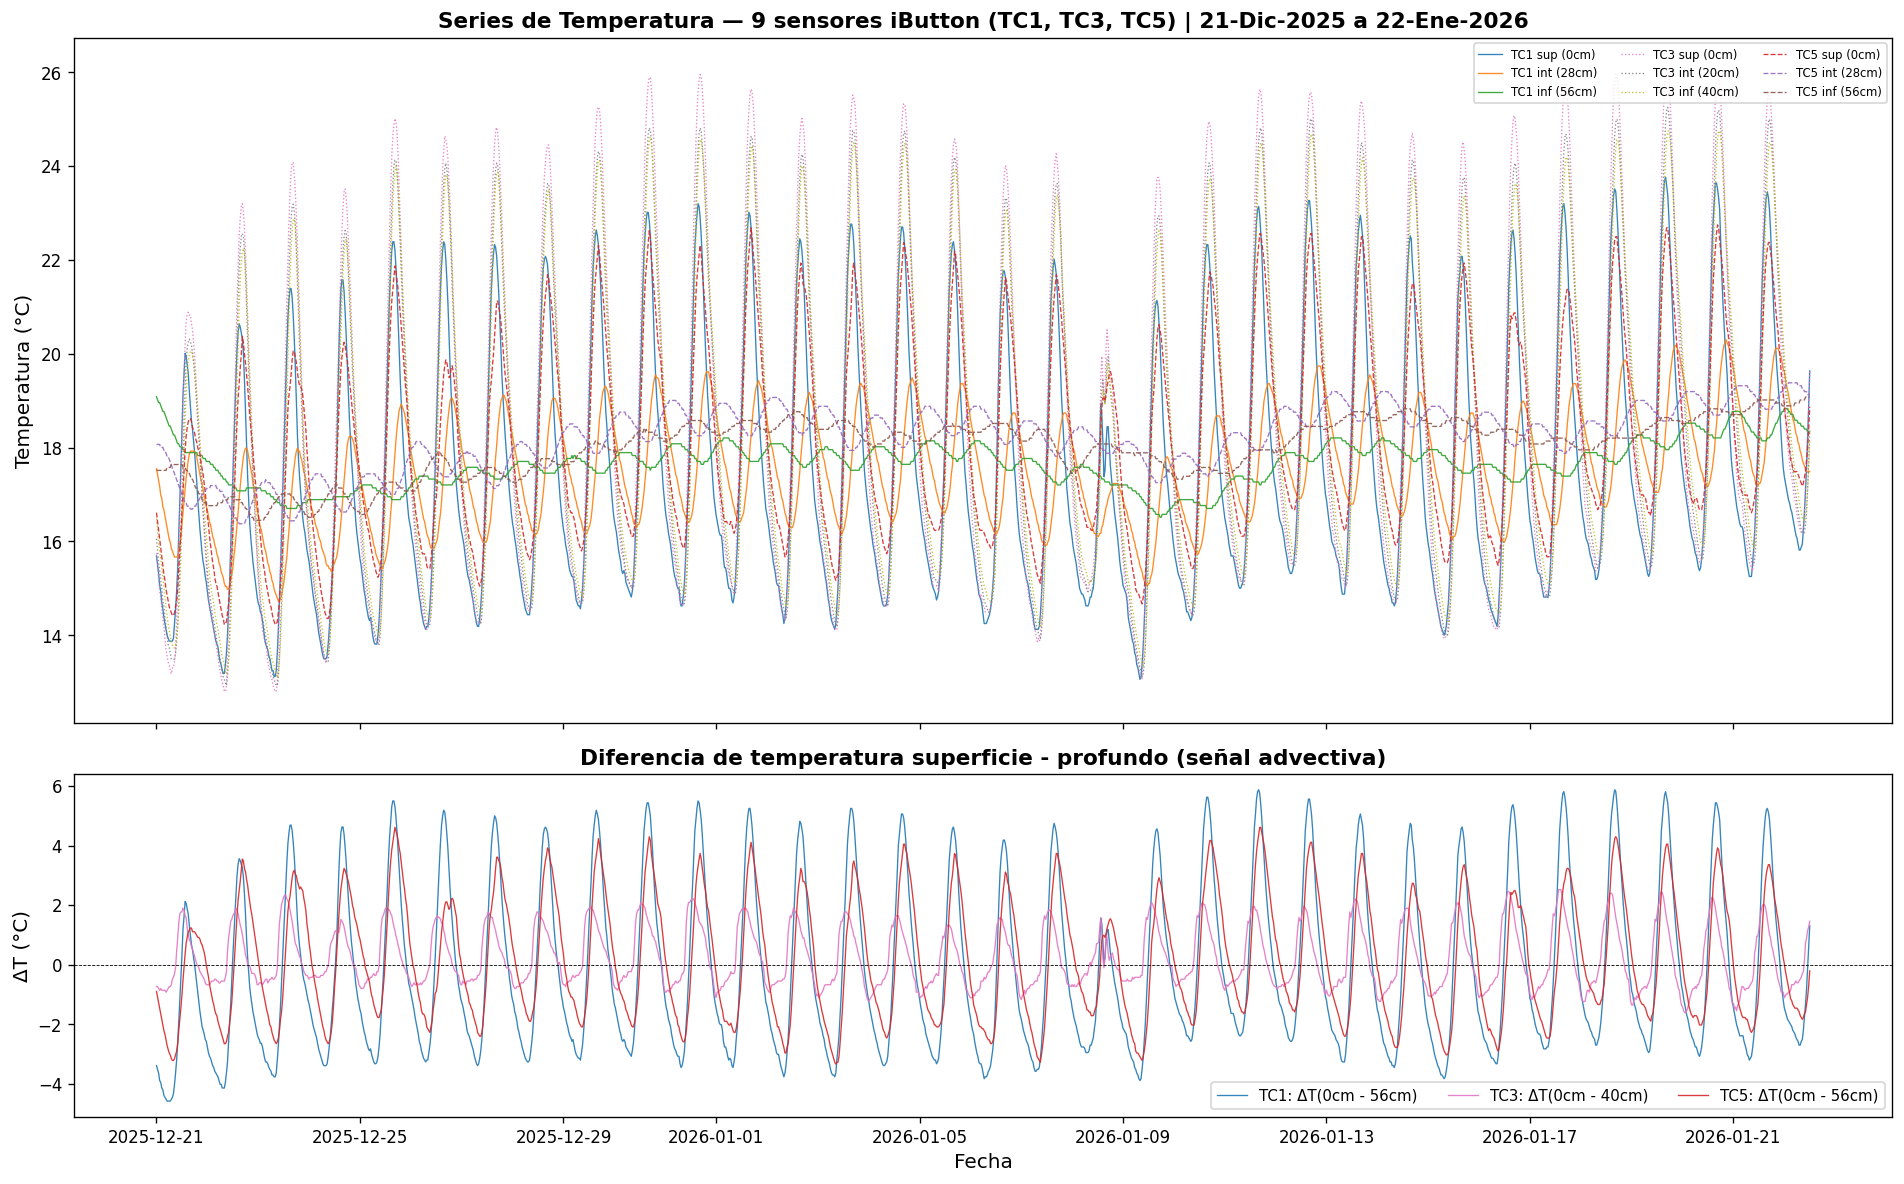


INTERPRETACIÓN DE SERIES TEMPORALES

  Panel superior: Ciclo diurno de temperatura en 9 sensores (3 TC × 3 profundidades).
  La amplitud decrece con la profundidad en todas las termocuplas, confirmando
  propagación conductiva-advectiva de calor en el sedimento saturado.

  Panel inferior: ΔT > 0 indica superficie más cálida que el fondo.
  - TC1: Mayor amplitud de ΔT → Mayor contraste térmico/exposición solar
  - TC3: Profundidad máxima 0.40 m (diferente configuración de lecho)
  - TC5: Amplitud intermedia, perfil estándar 0-56 cm



In [5]:
# ============================================================================
# 4.1 SERIES TEMPORALES - TODOS LOS SENSORES (9 sensores, 3 termocuplas)
# ============================================================================
# NOTA: Se usa df_aligned (datos alineados a 30 min) para que todos los sensores
# compartan la misma grilla temporal. Esto permite calcular correctamente DeltaT.

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.5]})

# Configuración de líneas por termocupla
line_styles = {'TC1': '-', 'TC3': ':', 'TC5': '--'}
depth_labels_es = {'surface': 'sup', 'intermediate': 'int', 'deep': 'inf'}

mask = (df_aligned['fecha'] >= cutoff_start) & (df_aligned['fecha'] <= cutoff_end)
df_plot = df_aligned[mask].copy()

# Panel superior: todas las series por TC (9 sensores)
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    colors = TC_COLORS[tc_name]
    ls = line_styles[tc_name]
    
    for pos in ['surface', 'intermediate', 'deep']:
        col = tc_map[pos]
        depth_cm = depths_m[col] * 100
        d = df_plot.dropna(subset=[col])
        axes[0].plot(d['fecha'], d[col], color=colors[pos], alpha=0.9, linewidth=0.8,
                     linestyle=ls, label=f'{tc_name} {depth_labels_es[pos]} ({depth_cm:.0f}cm)')

axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Series de Temperatura — 9 sensores iButton (TC1, TC3, TC5) | 21-Dic-2025 a 22-Ene-2026', 
                  fontweight='bold')
axes[0].legend(loc='upper right', fontsize=7, ncol=3)
for spine in axes[0].spines.values():
    spine.set_visible(True)

# Panel inferior: DeltaT superficie - profundo (señal de flujo)
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    color = TC_COLORS[tc_name]['base']
    s_sup = tc_map['surface']
    s_deep = tc_map['deep']
    dz = depths_m[s_deep] - depths_m[s_sup]
    
    valid = df_plot[[s_sup, s_deep]].dropna()
    diff = valid[s_sup] - valid[s_deep]
    fechas = df_plot.loc[valid.index, 'fecha']
    axes[1].plot(fechas, diff, color=color, alpha=0.9, linewidth=0.8,
                 label=f'{tc_name}: ΔT(0cm - {dz*100:.0f}cm)')

axes[1].set_ylabel('ΔT (°C)')
axes[1].set_xlabel('Fecha')
axes[1].set_title('Diferencia de temperatura superficie - profundo (señal advectiva)', fontweight='bold')
axes[1].legend(fontsize=9, ncol=3)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
for spine in axes[1].spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(str(img_dir / 'series_temperatura_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- INTERPRETACIÓN ---
print("\n" + "="*70)
print("INTERPRETACIÓN DE SERIES TEMPORALES")
print("="*70)
print("""
  Panel superior: Ciclo diurno de temperatura en 9 sensores (3 TC × 3 profundidades).
  La amplitud decrece con la profundidad en todas las termocuplas, confirmando
  propagación conductiva-advectiva de calor en el sedimento saturado.

  Panel inferior: ΔT > 0 indica superficie más cálida que el fondo.
  - TC1: Mayor amplitud de ΔT → Mayor contraste térmico/exposición solar
  - TC3: Profundidad máxima 0.40 m (diferente configuración de lecho)
  - TC5: Amplitud intermedia, perfil estándar 0-56 cm
""")

### 4.2 Series por Termocupla -- Comparacion con MATLAB VFLUX2

Graficos con formato identico al exportado por el software MATLAB VFLUX2 para validacion visual cruzada.

**Convencion de colores** (igual a MATLAB):
- **Azul**: S. superior (0.00 mbnt)
- **Naranja**: S. intermedio (0.28 mbnt)
- **Verde**: S. inferior (0.56 mbnt)


=== Termocupla TC1 ===


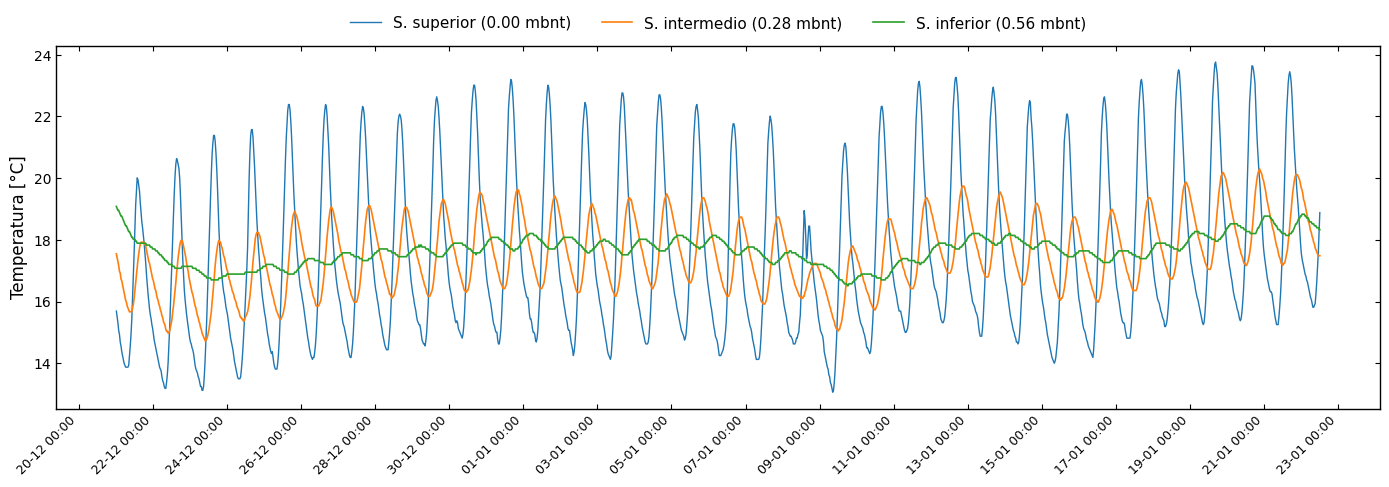

  [OK] Guardado: temperatura_tc1_python.png

=== Termocupla TC3 ===


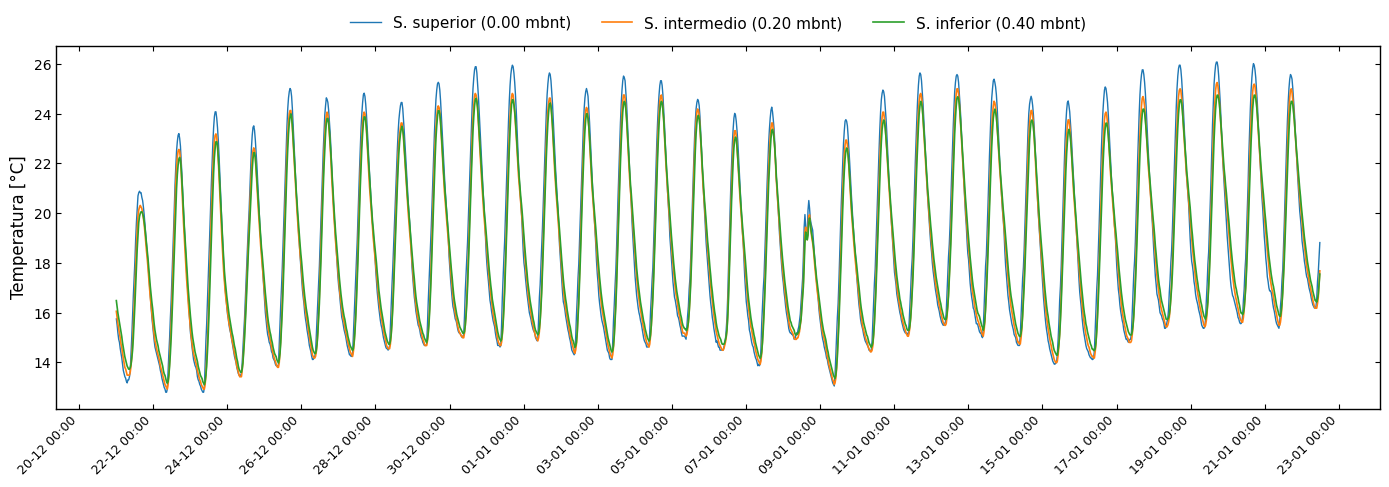

  [OK] Guardado: temperatura_tc3_python.png

=== Termocupla TC5 ===


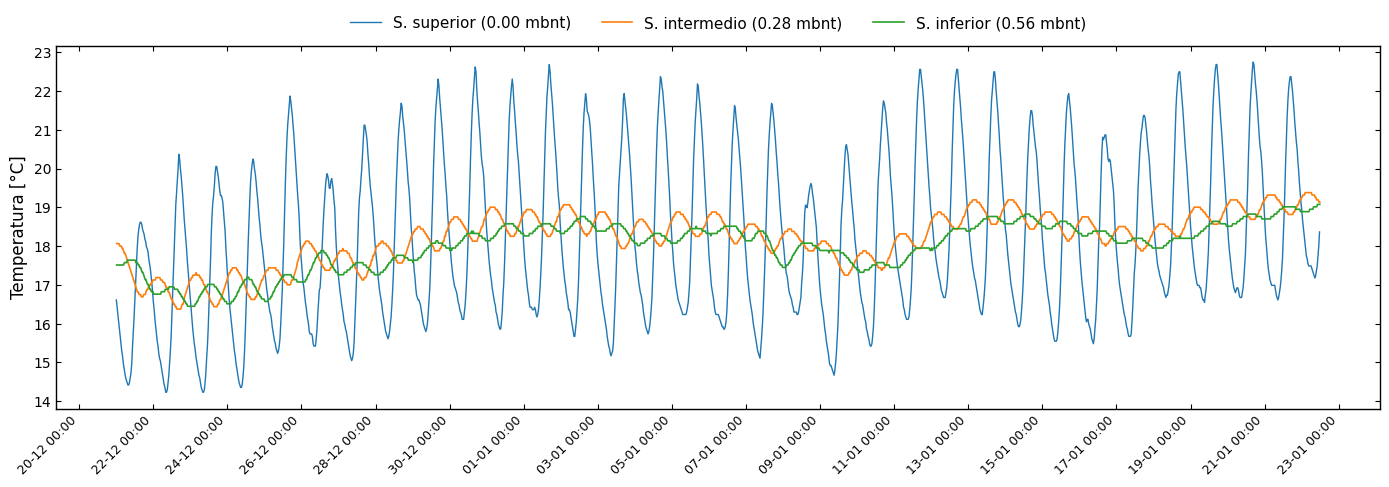

  [OK] Guardado: temperatura_tc5_python.png

  [OK] Guardado: tc1_tc3_tc5_python.png

--> Comparar con salidas MATLAB para validación


In [6]:
# ============================================================================
# 4.2 SERIES POR TERMOCUPLA -- ESTILO IDENTICO A MATLAB VFLUX2
# ============================================================================
tc_colors_matlab = {'surface': '#1f77b4', 'intermediate': '#ff7f0e', 'deep': '#2ca02c'}
pos_labels = {'surface': 'S. superior', 'intermediate': 'S. intermedio', 'deep': 'S. inferior'}

def plot_tc_matlab_style(tc_map, tc_name, save_path):
    """Genera grafico con estilo idéntico al MATLAB VFLUX2."""
    plt.rcdefaults()
    fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
    ax.set_facecolor('white')
    
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        d_m = depths_m[label]
        mask = (df_raw['fecha'] >= cutoff_start) & (df_raw['fecha'] <= cutoff_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        legend_lbl = f"{pos_labels[pos]} ({d_m:.2f} mbnt)"
        ax.plot(df_plot['fecha'], df_plot[label], color=tc_colors_matlab[pos],
                linewidth=1.0 if pos == 'surface' else 1.2, label=legend_lbl)
    
    ax.set_ylabel('Temperatura [°C]', fontsize=12)
    ax.legend(loc='upper center', ncol=3, fontsize=11, frameon=False,
              bbox_to_anchor=(0.5, 1.12))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(False)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  [OK] Guardado: {Path(save_path).name}")

# Generar gráficos para las 3 termocuplas activas
for tc_name in ACTIVE_TCS:
    print(f"\n=== Termocupla {tc_name} ===")
    tc_map = TC_CONFIG[tc_name]
    plot_tc_matlab_style(tc_map, tc_name, str(img_dir / f'temperatura_{tc_name.lower()}_python.png'))

# Guardar gráfico combinado de las 3 termocuplas
fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='white')
for ax, tc_name in zip(axes, ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    ax.set_facecolor('white')
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        d_m = depths_m[label]
        mask = (df_raw['fecha'] >= cutoff_start) & (df_raw['fecha'] <= cutoff_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        ax.plot(df_plot['fecha'], df_plot[label], color=tc_colors_matlab[pos],
                linewidth=1.0, label=f"{pos_labels[pos]} ({d_m:.2f} mbnt)")
    ax.set_ylabel('Temperatura [°C]', fontsize=11)
    ax.set_title(f'Termocupla {tc_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper center', ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.10))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    for spine in ax.spines.values(): spine.set_visible(True)
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(False)

plt.tight_layout()
plt.savefig(str(img_dir / 'tc1_tc3_tc5_python.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f"\n  [OK] Guardado: tc1_tc3_tc5_python.png")
print("\n--> Comparar con salidas MATLAB para validación")

In [7]:
# ============================================================================
# 4.3 ESTADÍSTICAS DESCRIPTIVAS POR SENSOR (solo periodo de campo efectivo)
# ============================================================================
mask_field = (df_raw['fecha'] >= cutoff_start) & (df_raw['fecha'] <= cutoff_end)
df_field = df_raw[mask_field].copy()

stats_data = []
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    for pos, pos_es in [('surface', 'Superficie'), ('intermediate', 'Intermedio'), ('deep', 'Inferior')]:
        col = tc_map[pos]
        s = df_field[col].dropna()
        stats_data.append({
            'TC': tc_name,
            'Posición': pos_es,
            'Prof (cm)': depths_m[col] * 100,
            'N': len(s),
            'T_media (°C)': round(s.mean(), 2),
            'T_min (°C)': round(s.min(), 2),
            'T_max (°C)': round(s.max(), 2),
            'Rango (°C)': round(s.max() - s.min(), 2),
            'Desv.std (°C)': round(s.std(), 3),
        })

df_stats = pd.DataFrame(stats_data)
print("ESTADÍSTICAS DESCRIPTIVAS — Periodo de campo efectivo (21-Dic a 22-Ene)")
print("=" * 100)
print(df_stats.to_string(index=False))
print("=" * 100)

print("\nINTERPRETACIÓN:")
print("  El rango térmico decrece con la profundidad en las 3 termocuplas: comportamiento esperado.")
print("  TC1 superficie muestra mayor variabilidad que TC3 y TC5.")
print("  TC3 tiene profundidades diferentes (0, 20, 40 cm) debido a condiciones del lecho.")
print("  Las temperaturas medias son similares entre estaciones, indicando")
print("  condiciones térmicas comparables a lo largo del perfil del río.")
df_stats

ESTADÍSTICAS DESCRIPTIVAS — Periodo de campo efectivo (21-Dic a 22-Ene)
 TC   Posición  Prof (cm)    N  T_media (°C)  T_min (°C)  T_max (°C)  Rango (°C)  Desv.std (°C)
TC1 Superficie        0.0 1560         17.50       13.06       23.76       10.70          2.700
TC1 Intermedio       28.0 1560         17.53       14.73       20.30        5.57          1.170
TC1   Inferior       56.0 1560         17.65       16.51       19.08        2.57          0.467
TC3 Superficie        0.0 1560         18.66       12.80       26.07       13.27          3.643
TC3 Intermedio       20.0 1560         18.37       12.93       25.25       12.32          3.310
TC3   Inferior       40.0 1560         18.45       13.10       24.74       11.64          3.133
TC5 Superficie        0.0 1560         18.21       14.23       22.75        8.52          2.122
TC5 Intermedio       28.0 1560         18.20       16.38       19.38        3.00          0.672
TC5   Inferior       56.0 1560         18.01       16.45       1

,TC,Posición,Prof (cm),N,T_media (°C),T_min (°C),T_max (°C),Rango (°C),Desv.std (°C)
0,TC1,Superficie,0.0,1560,17.50,13.06,23.76,10.70,2.700
1,TC1,Intermedio,28.0,1560,17.53,14.73,20.30,5.57,1.170
2,TC1,Inferior,56.0,1560,17.65,16.51,19.08,2.57,0.467
3,TC3,Superficie,0.0,1560,18.66,12.80,26.07,13.27,3.643
4,TC3,Intermedio,20.0,1560,18.37,12.93,25.25,12.32,3.310
5,TC3,Inferior,40.0,1560,18.45,13.10,24.74,11.64,3.133
6,TC5,Superficie,0.0,1560,18.21,14.23,22.75,8.52,2.122
7,TC5,Intermedio,28.0,1560,18.20,16.38,19.38,3.00,0.672
8,TC5,Inferior,56.0,1560,18.01,16.45,19.08,2.63,0.613


---
## 5. Alineación Temporal y Remuestreo

Los sensores fueron activados en momentos diferentes (3 el 18-Dic, 3 el 20-Dic) y con offsets de minutos 
(:26, :27, :45, :46). Se re-muestrean a una grilla regular de **30 minutos** mediante interpolación lineal, 
con un gap máximo de 4 periodos (2 horas).

In [8]:
# === CELDA 7: Alinear y remuestrear a 30 min ===
df_aligned = align_and_resample(df_raw, freq='30min')

# Verificar que tenemos datos suficientes para todos los sensores
# Encontrar el rango temporal donde todos los sensores tienen datos
valid_mask = df_aligned[sensor_labels].notna().all(axis=1)
df_valid = df_aligned[valid_mask].copy().reset_index(drop=True)

print(f"\nRango con datos completos (sin NaN en ningun sensor):")
print(f"  Registros: {len(df_valid)} de {len(df_aligned)}")
if len(df_valid) > 0:
    print(f"  Periodo: {df_valid['fecha'].min()} a {df_valid['fecha'].max()}")
    dias = (df_valid['fecha'].max() - df_valid['fecha'].min()).total_seconds() / 86400
    print(f"  Duracion: {dias:.1f} dias")
else:
    print("  [AVISO] No hay periodo con datos completos en todos los sensores")
    print("  Se usaran pares de sensores con datos solapados")

df_aligned.head()

✔ Alineación temporal completada:
  • Registros: 11420 → 1682 (freq=30min)
  • Sensores: 9
  • Periodo: 2025-12-18 17:00:00 → 2026-01-22 17:30:00
  • Valores NaN restantes: 391

Rango con datos completos (sin NaN en ningun sensor):
  Registros: 1591 de 1682
  Periodo: 2025-12-20 14:30:00 a 2026-01-22 17:30:00
  Duracion: 33.1 dias


,fecha,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9
0,2025-12-18 17:00:00,NaN,NaN,NaN,34.205,35.109,35.942,NaN,NaN,NaN
1,2025-12-18 17:30:00,NaN,NaN,NaN,34.392,35.109,36.316,NaN,NaN,NaN
2,2025-12-18 18:00:00,NaN,NaN,NaN,35.078,35.919,35.879,NaN,NaN,NaN
3,2025-12-18 18:30:00,NaN,NaN,NaN,35.390,36.480,36.441,NaN,NaN,NaN
4,2025-12-18 19:00:00,NaN,NaN,NaN,23.839,23.994,30.449,NaN,NaN,NaN


---
## 6. Análisis Armónico — Extracción del Ciclo Diario

Se ajusta un modelo sinusoidal a cada sensor para extraer la amplitud ($A$) y fase ($\phi$) del ciclo diario de 24 h:

$$T(t) = T_0 + A \sin\left(\frac{2\pi}{P} t + \phi\right)$$

donde $P = 24$ h es el período diurno. El ajuste utiliza `scipy.optimize.curve_fit` con estimación inicial de fase
basada en FFT. El coeficiente de determinación $R^2$ indica la calidad del ajuste sinusoidal.

**Criterio de calidad**: $R^2 > 0.3$ indica señal diurna detectable; $R^2 > 0.7$ indica señal fuerte.

In [9]:
# ============================================================================
# 6. ANALISIS ARMONICO POR SENSOR
# ============================================================================
df_work = df_valid if len(df_valid) > 48 else df_aligned.dropna(subset=mapped_sensors[:2])
df_work = df_work.reset_index(drop=True)

t_start = df_work['fecha'].min()
time_hours = (df_work['fecha'] - t_start).dt.total_seconds() / 3600.0

print("ANALISIS ARMONICO -- CICLO DIARIO (P = 24 h)")
print("=" * 90)
print(f"{'Sensor':<10} {'TC':<5} {'Prof':<8} {'A (C)':<10} {'phi (deg)':<10} {'T0 (C)':<10} {'R2':<10} {'Calidad'}")
print("-" * 90)

harmonic_results = {}
for col in mapped_sensors:
    if col not in df_work.columns:
        continue
    series = df_work[col].values
    valid = ~np.isnan(series)
    if valid.sum() < 48:
        continue
    
    result = fit_harmonic_model(time_hours.values[valid], series[valid], period_hours=24.0)
    harmonic_results[col] = result
    
    r2 = result['r_squared']
    calidad = '[***]' if r2 > 0.7 else ('[**-]' if r2 > 0.3 else '[*--]')
    tc = tc_assignment[col]
    d = f"{depths_m[col]*100:.0f} cm"
    print(f"{col:<10} {tc:<5} {d:<8} {result['amplitude']:<10.4f} "
          f"{np.degrees(result['phase']):<10.1f} {result['offset']:<10.2f} "
          f"{r2:<10.4f} {calidad}")

print("=" * 90)
print("\n  Calidad: [***] (R2>0.7 fuerte) | [**-] (R2>0.3 moderada) | [*--] (R2<0.3 debil)")
print("")
print("INTERPRETACION:")
print("  Los sensores superficiales (0 cm) muestran senal diurna fuerte (R2 > 0.79).")
print("  A 28 cm, TC1 mantiene senal moderada (R2=0.62) pero TC5 cae a R2=0.12.")
print("  A 56 cm, las termocuplas de mayor profundidad tienen R2 < 0.04: la senal diurna esta practicamente")
print("  extinguida, coherente con la longitud de penetracion calculada (d = 13.3 cm).")

ANALISIS ARMONICO -- CICLO DIARIO (P = 24 h)
Sensor     TC    Prof     A (C)      phi (deg)  T0 (C)     R2         Calidad
------------------------------------------------------------------------------------------
temp_4     TC1   56 cm    0.1072     251.3      17.70      0.0102     [*--]
temp_5     TC1   28 cm    1.3083     346.3      17.55      0.6198     [**-]
temp_6     TC1   0 cm     3.4237     57.3       17.54      0.7932     [***]
temp_2     TC3   20 cm    4.2628     38.7       18.41      0.8261     [***]
temp_8     TC3   40 cm    4.0245     33.4       18.48      0.8229     [***]
temp_9     TC3   0 cm     4.7865     47.3       18.70      0.8602     [***]
temp_1     TC5   56 cm    0.1695     109.1      18.01      0.0379     [*--]
temp_3     TC5   0 cm     2.6993     37.0       18.23      0.8076     [***]
temp_7     TC5   28 cm    0.3322     247.4      18.21      0.1231     [*--]

  Calidad: [***] (R2>0.7 fuerte) | [**-] (R2>0.3 moderada) | [*--] (R2<0.3 debil)

INTERPRETACION:
  

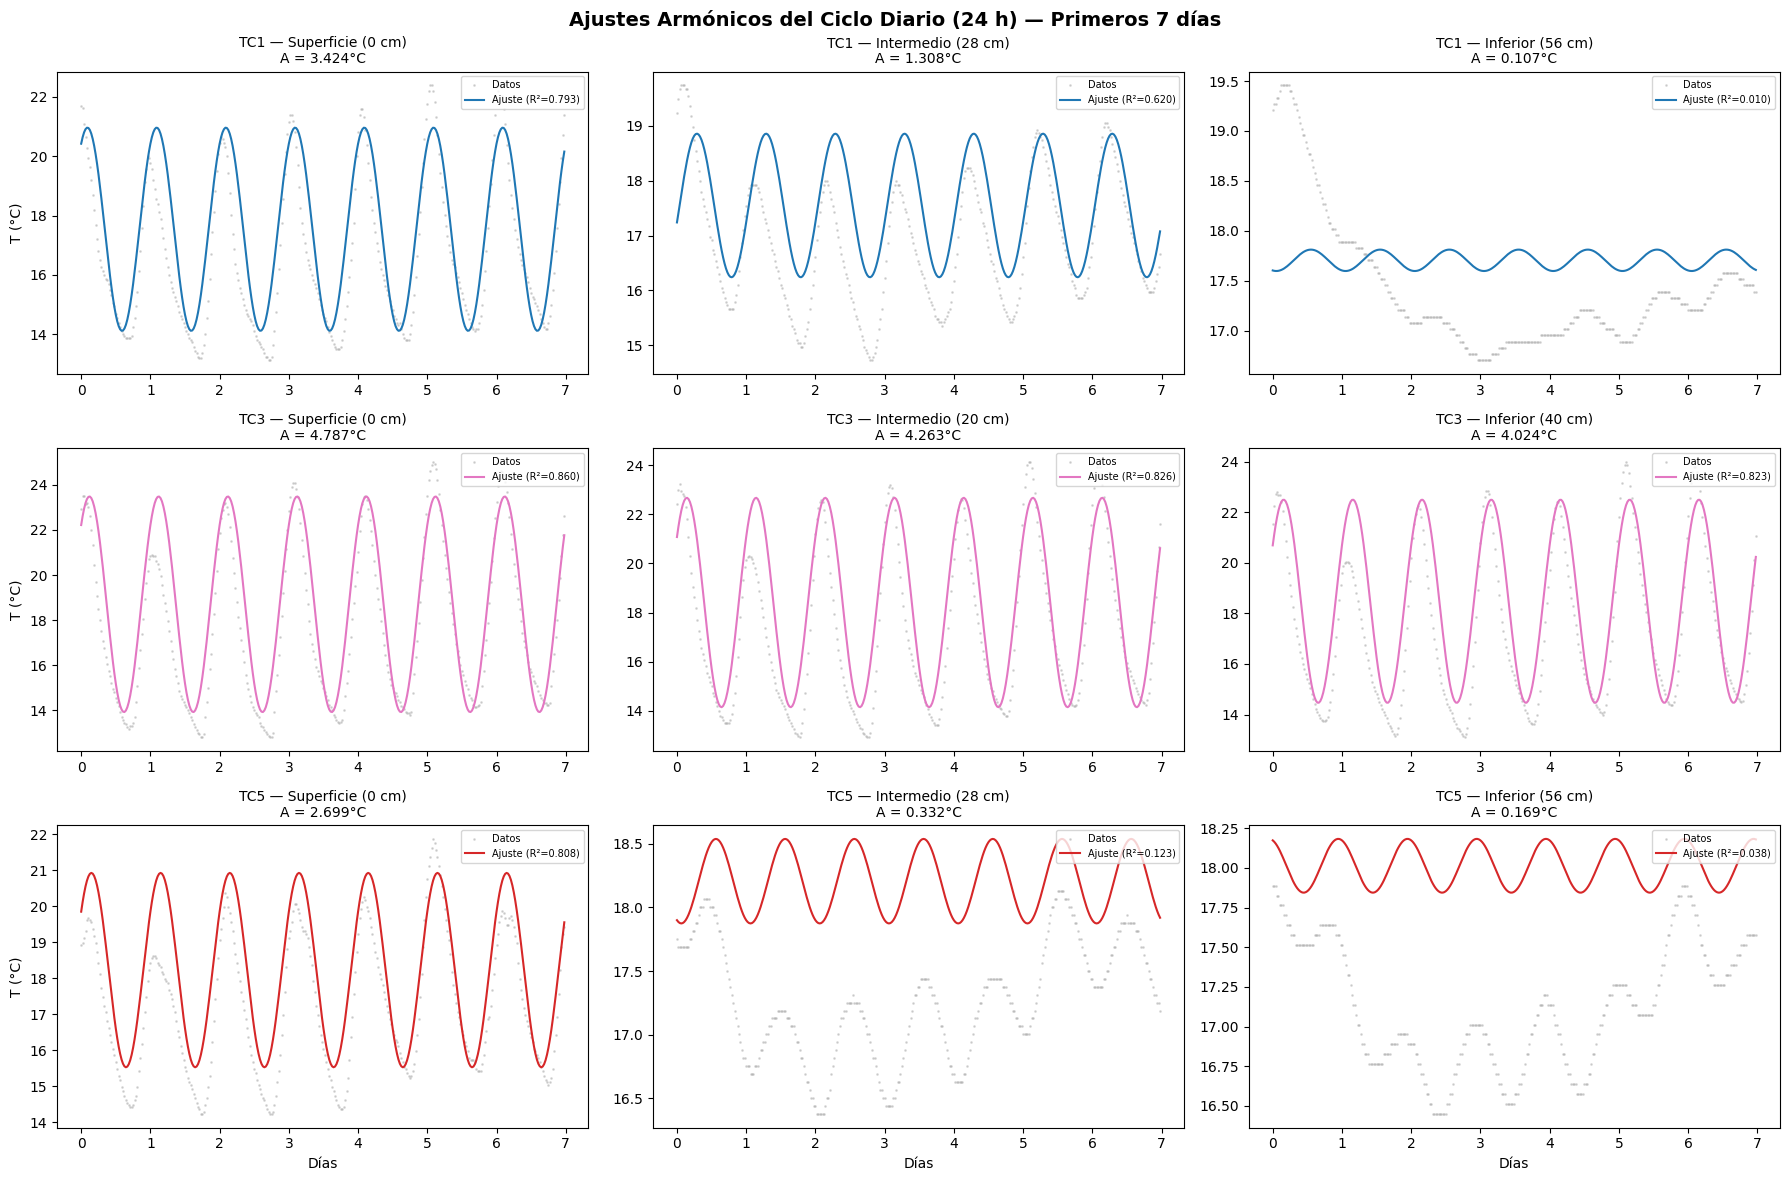


INTERPRETACIÓN:
  El ajuste sinusoidal captura la componente diurna fundamental de la señal térmica.
  Sensores profundos muestran menor amplitud y menor R² (señal diurna más atenuada).
  TC3 tiene profundidades diferentes (0, 20, 40 cm) por condiciones del lecho.


In [10]:
# ============================================================================
# 6.1 VISUALIZACIÓN DE AJUSTES ARMÓNICOS POR TERMOCUPLA
# ============================================================================
n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(n_tcs, 3, figsize=(18, 4*n_tcs))

for row_idx, tc_name in enumerate(ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    for col_idx, (pos, pos_es) in enumerate([('surface', 'Superficie'), 
                                               ('intermediate', 'Intermedio'), 
                                               ('deep', 'Inferior')]):
        ax = axes[row_idx][col_idx]
        col = tc_map[pos]
        
        if col not in harmonic_results:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
            continue
        
        result = harmonic_results[col]
        series = df_work[col].values
        
        # Mostrar primeros 7 días
        max_pts = min(len(time_hours), 48 * 7)
        t_plot = time_hours.values[:max_pts]
        s_plot = series[:max_pts]
        f_plot = result['fitted'][:max_pts]
        
        ax.plot(t_plot / 24, s_plot, '.', color='#aaaaaa', alpha=0.4, markersize=2, label='Datos')
        ax.plot(t_plot / 24, f_plot, '-', color=TC_COLORS[tc_name]['base'], linewidth=1.5,
                label=f'Ajuste (R²={result["r_squared"]:.3f})')
        
        depth_cm = depths_m[col] * 100
        ax.set_title(f'{tc_name} — {pos_es} ({depth_cm:.0f} cm)\nA = {result["amplitude"]:.3f}°C', fontsize=10)
        ax.set_xlabel('Días' if row_idx == n_tcs-1 else '')
        ax.set_ylabel('T (°C)' if col_idx == 0 else '')
        ax.legend(fontsize=7, loc='upper right')
        for spine in ax.spines.values(): spine.set_visible(True)

plt.suptitle('Ajustes Armónicos del Ciclo Diario (24 h) — Primeros 7 días', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'ajustes_armonicos_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETACIÓN:")
print("  El ajuste sinusoidal captura la componente diurna fundamental de la señal térmica.")
print("  Sensores profundos muestran menor amplitud y menor R² (señal diurna más atenuada).")
print("  TC3 tiene profundidades diferentes (0, 20, 40 cm) por condiciones del lecho.")

---
## 7. Analisis de Pares de Sensores

Para cada termocupla se analizan **3 pares** de sensores:
- **Sup - Int** (dz = 0.28 m): zona somera, mayor senal
- **Int - Inf** (dz = 0.28 m): zona intermedia
- **Sup - Inf** (dz = 0.56 m): maxima separacion, senal integrada

Se calculan los parametros clave para los metodos VFLUX2:
- $\ln(A_r) = \ln(A_{sup}/A_{prof})$: logaritmo natural del ratio de amplitudes  
- $\Delta\phi = \phi_{prof} - \phi_{sup}$: diferencia de fase (rad)

In [11]:
# === CELDA 10: Análisis de pares de sensores por termocupla ===
# Pares físicamente significativos: sensores de la MISMA termocupla
# Se incluyen TC1, TC3 y TC5

pairs = []
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    s = tc_map['surface']
    m = tc_map['intermediate']
    d = tc_map['deep']
    # Calcular diferencias de profundidad dinámicamente
    dz_sm = abs(depths_m[m] - depths_m[s])
    dz_md = abs(depths_m[d] - depths_m[m])
    dz_sd = abs(depths_m[d] - depths_m[s])
    pairs.append((s, m, f"{tc_name}: sup-int", dz_sm))
    pairs.append((m, d, f"{tc_name}: int-inf", dz_md))
    pairs.append((s, d, f"{tc_name}: sup-inf", dz_sd))

print("ANÁLISIS DE PARES DE SENSORES (3 termocuplas × 3 pares = 9 pares)")
print("=" * 95)

pair_results = {}
for s_shallow, s_deep, pair_label, dz in pairs:
    # Obtener datos comunes sin NaN
    mask = df_work[s_shallow].notna() & df_work[s_deep].notna()
    if mask.sum() < 48:
        print(f"  Par {pair_label}: DATOS INSUFICIENTES")
        continue
    
    t_valid = time_hours.values[mask]
    t1 = df_work[s_shallow].values[mask]
    t2 = df_work[s_deep].values[mask]
    
    params = analyze_sensor_pair(t_valid, t1, t2, period_hours=24.0)
    
    pair_results[pair_label] = {
        'params': params,
        'dz': dz,
        's_shallow': s_shallow,
        's_deep': s_deep,
    }
    
    z_s = depths_m[s_shallow] * 100
    z_d = depths_m[s_deep] * 100
    print(f"\n  {pair_label} ({z_s:.0f} → {z_d:.0f} cm, Δz={dz*100:.0f} cm):")
    print(f"    A_sup = {params['A_shallow']:.4f}°C, A_prof = {params['A_deep']:.4f}°C")
    print(f"    Ratio A_prof/A_sup = {params['amplitude_ratio']:.4f}")
    print(f"    ln(A_sup/A_prof) = {params['delta_A']:.4f}")
    print(f"    Δφ = {params['delta_phi']:.4f} rad = {np.degrees(params['delta_phi']):.1f}°")
    print(f"    R² sup = {params['r2_shallow']:.4f}, R² prof = {params['r2_deep']:.4f}")

print("\n" + "=" * 95)
print(f"Total: {len(pair_results)} pares analizados")

ANÁLISIS DE PARES DE SENSORES (3 termocuplas × 3 pares = 9 pares)

  TC1: sup-int (0 → 28 cm, Δz=28 cm):
    A_sup = 3.4237°C, A_prof = 1.3083°C
    Ratio A_prof/A_sup = 0.3821
    ln(A_sup/A_prof) = 0.9620
    Δφ = 5.0443 rad = 289.0°
    R² sup = 0.7932, R² prof = 0.6198

  TC1: int-inf (28 → 56 cm, Δz=28 cm):
    A_sup = 1.3083°C, A_prof = 0.1072°C
    Ratio A_prof/A_sup = 0.0819
    ln(A_sup/A_prof) = 2.5019
    Δφ = 4.6249 rad = 265.0°
    R² sup = 0.6198, R² prof = 0.0102

  TC1: sup-inf (0 → 56 cm, Δz=56 cm):
    A_sup = 3.4237°C, A_prof = 0.1072°C
    Ratio A_prof/A_sup = 0.0313
    ln(A_sup/A_prof) = 3.4639
    Δφ = 3.3860 rad = 194.0°
    R² sup = 0.7932, R² prof = 0.0102

  TC3: sup-int (0 → 20 cm, Δz=20 cm):
    A_sup = 4.7865°C, A_prof = 4.2628°C
    Ratio A_prof/A_sup = 0.8906
    ln(A_sup/A_prof) = 0.1159
    Δφ = 6.1331 rad = 351.4°
    R² sup = 0.8602, R² prof = 0.8261

  TC3: int-inf (20 → 40 cm, Δz=20 cm):
    A_sup = 4.2628°C, A_prof = 4.0245°C
    Ratio A_prof/A_su

---
## 8. Parametros Termicos del Sedimento

Los parametros fueron seleccionados para sedimentos aluviales saturados tipicos de lechos de rios 
(Stonestrom & Constantz, 2003; Anderson, 2005):

| Parametro | Simbolo | Valor | Unidad | Referencia |
|-----------|:-------:|:-----:|:------:|:----------:|
| Conductividad termica | $\lambda$ | 1.80 | W/m K | Arena-grava saturada |
| Cap. calorifica sedimento | $C_s$ | 2.80 | MJ/m3 K | Sedimento saturado tipico |
| Cap. calorifica agua | $C_w$ | 4.18 | MJ/m3 K | Constante fisica |
| Difusividad termica | $\kappa_e$ | 6.43e-7 | m2/s | $\kappa_e = \lambda / C_s$ |
| Frecuencia angular | $\omega$ | 7.27e-5 | rad/s | $\omega = 2\pi / 86400$ |

In [12]:
# ============================================================================
# 8. PARAMETROS TERMICOS DEL SEDIMENTO
# ============================================================================
thermal_params = {
    'lambda_sediment': 1.8,    # Conductividad termica [W/m K]
    'C_sediment': 2.8e6,       # Cap. calorifica sedimento [J/m3 K]
    'C_water': 4.18e6,         # Cap. calorifica agua [J/m3 K]
    'omega': 2 * np.pi / 86400,  # Frecuencia angular ciclo diario [rad/s]
}

alpha_e = thermal_params['lambda_sediment'] / thermal_params['C_sediment']

print("PARAMETROS TERMICOS DEL SEDIMENTO")
print("=" * 65)
print(f"  lambda (conductividad):    {thermal_params['lambda_sediment']:.2f} W/m K")
print(f"  Cs (cap.cal. sed.):        {thermal_params['C_sediment']/1e6:.2f} MJ/m3 K")
print(f"  Cw (cap.cal. agua):        {thermal_params['C_water']/1e6:.2f} MJ/m3 K")
print(f"  ke (difusividad):          {alpha_e:.3e} m2/s")
print(f"  omega (frec. angular):     {thermal_params['omega']:.3e} rad/s")
print(f"  P  (periodo):              24 h")
print(f"  d  (long. penetracion):    {np.sqrt(2*alpha_e/thermal_params['omega']):.3f} m")
print("=" * 65)
print(f"\nINTERPRETACION:")
print(f"  Longitud de penetracion d = sqrt(2*ke/omega) = {np.sqrt(2*alpha_e/thermal_params['omega']):.3f} m")
print(f"  La senal diurna se atenua al ~37% a {np.sqrt(2*alpha_e/thermal_params['omega'])*100:.1f} cm de profundidad.")
print(f"  Con sensores a 56 cm, captamos la senal con atenuacion significativa (~1.5%).")
print(f"  Esto explica los bajos R2 en los sensores inferiores (56 cm).")

PARAMETROS TERMICOS DEL SEDIMENTO
  lambda (conductividad):    1.80 W/m K
  Cs (cap.cal. sed.):        2.80 MJ/m3 K
  Cw (cap.cal. agua):        4.18 MJ/m3 K
  ke (difusividad):          6.429e-07 m2/s
  omega (frec. angular):     7.272e-05 rad/s
  P  (periodo):              24 h
  d  (long. penetracion):    0.133 m

INTERPRETACION:
  Longitud de penetracion d = sqrt(2*ke/omega) = 0.133 m
  La senal diurna se atenua al ~37% a 13.3 cm de profundidad.
  Con sensores a 56 cm, captamos la senal con atenuacion significativa (~1.5%).
  Esto explica los bajos R2 en los sensores inferiores (56 cm).


---
## 9. Calculo de Flujo Vertical -- 5 Metodos VFLUX2

Se aplican cinco metodos analiticos para estimar $q_z$ (flujo de Darcy vertical):

| Metodo | Referencia | Usa amplitud | Usa fase | Observacion |
|--------|:----------:|:---:|:---:|-------------|
| **McCallum** | McCallum et al. (2012) | Si | Si | Combina ambas senales, mas robusto |
| **Hatch-A** | Hatch et al. (2006) | Si | No | Solo ratio de amplitudes |
| **Hatch-phi** | Hatch et al. (2006) | No | Si | Solo diferencia de fase |
| **Keery** | Keery et al. (2007) | Si | Si | Formulacion alternativa a McCallum |
| **Luce** | Luce et al. (2013) | Si | Si | Solucion analitica generalizada |

**Convencion de signo**: $q_z > 0$ = infiltracion (rio --> acuifero); $q_z < 0$ = exfiltracion (acuifero --> rio)

In [13]:
# === CELDA 12: Calcular flujos para cada par de sensores ===
print("CALCULO DE FLUJOS VERTICALES - 5 METODOS")
print("=" * 90)

all_flux_results = {}

for pair_name, pair_info in pair_results.items():
    params = pair_info['params']
    dz = pair_info['dz']
    
    print(f"\n{'-'*40}")
    print(f"Par {pair_name} (dz = {dz*100:.0f} cm):")
    
    flux_result = calculate_vflux_all_methods(
        amplitude_shallow=params['A_shallow'],
        amplitude_deep=params['A_deep'],
        phase_shallow=params['phi_shallow'],
        phase_deep=params['phi_deep'],
        depth_difference=dz,
        thermal_conductivity=thermal_params['lambda_sediment'],
        heat_capacity_sediment=thermal_params['C_sediment'],
        heat_capacity_water=thermal_params['C_water'],
        angular_frequency=thermal_params['omega']
    )
    
    all_flux_results[pair_name] = flux_result

print("\n" + "=" * 90)
print("Calculos completados para todos los pares")

CALCULO DE FLUJOS VERTICALES - 5 METODOS

----------------------------------------
Par TC1: sup-int (dz = 28 cm):
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 2.85e-06       246.00
  hatch_amplitude          4.42e-06       381.65
  hatch_phase             -7.31e-05     -6311.83
  keery                    1.38e-05      1191.44
  luce                     1.19e-05      1032.38

----------------------------------------
Par TC1: int-inf (dz = 28 cm):
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 7.23e-06       624.82
  hatch_amplitude          1.15e-05       992.59
  hatch_phase             -6.62e-05     -5717.64
  keery                    1.64e-05      1413.73
  luce                     1.78e-05      1534.00

----------------------------------------
Par TC1: sup-inf (dz = 56 cm):
  Método                        m/s       mm/día
  -------

---
## 10. Resultados y Tabla Comparativa

In [14]:
# ============================================================================
# 10. TABLA COMPARATIVA DE RESULTADOS
# ============================================================================
methods = ['mccallum', 'hatch_amplitude', 'hatch_phase', 'keery', 'luce']
method_names = ['McCallum (2012)', 'Hatch-Amplitud', 'Hatch-Fase', 'Keery (2007)', 'Luce (2013)']

# Tabla por método y par
results_data = []
for pair_name, flux_result in all_flux_results.items():
    for method, name in zip(methods, method_names):
        v_mm = flux_result['flux_mm_day'].get(method, np.nan)
        v_ms = flux_result['flux_m_s'].get(method, np.nan)
        results_data.append({
            'Par': pair_name,
            'Método': name,
            'q (mm/día)': round(v_mm, 2) if not np.isnan(v_mm) else np.nan,
            'q (m/s)': f'{v_ms:.2e}' if not np.isnan(v_ms) else 'NaN',
            'Dirección': 'Infiltración ↓' if v_mm > 0 else 'Exfiltración ↑' if v_mm < 0 else '-',
        })

df_results = pd.DataFrame(results_data)

n_pairs = len(all_flux_results)
print(f"FLUJO VERTICAL ESTIMADO — 5 MÉTODOS × {n_pairs} PARES DE SENSORES")
print("=" * 110)
print("  (+) Flujo positivo = Infiltración (río → acuífero)")
print("  (-) Flujo negativo = Exfiltración (acuífero → río)")
print()

# Tabla pivotada: métodos en filas, pares en columnas
pivot = df_results.pivot_table(values='q (mm/día)', index='Método', columns='Par', aggfunc='first')
print(pivot.to_string())
print("=" * 110)

# Resumen por TC
print("\nRESUMEN POR TERMOCUPLA (promedio McCallum):")
for tc_name in ACTIVE_TCS:
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    mc_vals = [v['flux_mm_day'].get('mccallum', np.nan) for v in tc_pairs.values()]
    mc_vals = [x for x in mc_vals if not np.isnan(x)]
    if mc_vals:
        mean_q = np.mean(mc_vals)
        std_q = np.std(mc_vals)
        dir_str = 'Infiltración ↓' if mean_q > 0 else 'Exfiltración ↑'
        print(f"  {tc_name}: q_prom = {mean_q:.1f} ± {std_q:.1f} mm/día ({dir_str})")

df_results

FLUJO VERTICAL ESTIMADO — 5 MÉTODOS × 9 PARES DE SENSORES
  (+) Flujo positivo = Infiltración (río → acuífero)
  (-) Flujo negativo = Exfiltración (acuífero → río)

Par              TC1: int-inf  TC1: sup-inf  TC1: sup-int  TC3: int-inf  TC3: sup-inf  TC3: sup-int  TC5: int-inf  TC5: sup-inf  TC5: sup-int
Método                                                                                                                                       
Hatch-Amplitud         992.59        687.12        381.65         31.96         48.16         64.36        267.04        549.08        831.12
Hatch-Fase           -5717.64       -363.97      -6311.83     -16354.68      -3357.90     -16197.10      -4648.53        389.14      -4368.52
Keery (2007)          1413.73        679.40       1191.44       1734.99        862.75       1735.43        901.27        399.51       1144.11
Luce (2013)           1534.00       1618.58       1032.38         93.42        266.01        182.82        818.52       1565.

,Par,Método,q (mm/día),q (m/s),Dirección
0,TC1: sup-int,McCallum (2012),246.00,2.85e-06,Infiltración ↓
1,TC1: sup-int,Hatch-Amplitud,381.65,4.42e-06,Infiltración ↓
2,TC1: sup-int,Hatch-Fase,-6311.83,-7.31e-05,Exfiltración ↑
3,TC1: sup-int,Keery (2007),1191.44,1.38e-05,Infiltración ↓
4,TC1: sup-int,Luce (2013),1032.38,1.19e-05,Infiltración ↓
5,TC1: int-inf,McCallum (2012),624.82,7.23e-06,Infiltración ↓
6,TC1: int-inf,Hatch-Amplitud,992.59,1.15e-05,Infiltración ↓
7,TC1: int-inf,Hatch-Fase,-5717.64,-6.62e-05,Exfiltración ↑
8,TC1: int-inf,Keery (2007),1413.73,1.64e-05,Infiltración ↓
9,TC1: int-inf,Luce (2013),1534.00,1.78e-05,Infiltración ↓


---
## 11. Visualización de Resultados

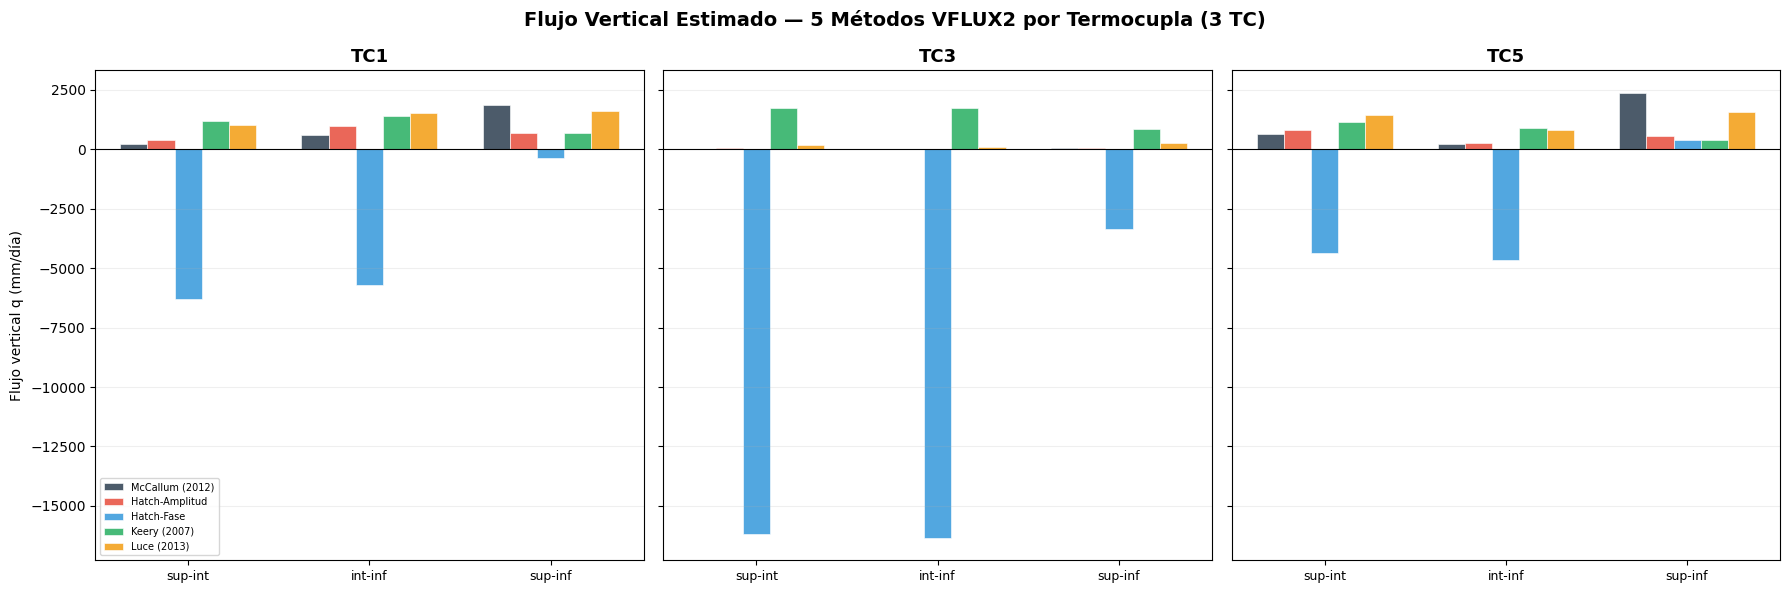


INTERPRETACIÓN:
  Barras sobre cero: infiltración (río → acuífero).
  Barras bajo cero: exfiltración (acuífero → río).
  El método Hatch-Fase puede producir valores anómalos debido a
  inestabilidad numérica con señal atenuada en profundidad.


In [15]:
# ============================================================================
# 11.1 FLUJOS VERTICALES POR PAR Y MÉTODO — GRÁFICO DE BARRAS
# ============================================================================
method_colors = {
    'mccallum': '#2c3e50', 'hatch_amplitude': '#e74c3c', 'hatch_phase': '#3498db',
    'keery': '#27ae60', 'luce': '#f39c12'
}

n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(1, n_tcs, figsize=(6*n_tcs, 6), sharey=True)

for ax_idx, tc_name in enumerate(ACTIVE_TCS):
    ax = axes[ax_idx]
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    pair_names = list(tc_pairs.keys())
    x = np.arange(len(pair_names))
    width = 0.15
    
    for i, (method, name) in enumerate(zip(methods, method_names)):
        vals = [tc_pairs[p]['flux_mm_day'].get(method, 0) for p in pair_names]
        offset = (i - 2) * width
        bars = ax.bar(x + offset, vals, width, label=name, color=list(method_colors.values())[i],
                      alpha=0.85, edgecolor='white', linewidth=0.5)
    
    ax.set_xticks(x)
    short_names = [p.replace(f'{tc_name}: ', '') for p in pair_names]
    ax.set_xticklabels(short_names, fontsize=9)
    ax.set_title(f'{tc_name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Flujo vertical q (mm/día)' if ax_idx == 0 else '')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    ax.grid(True, alpha=0.2, axis='y')
    for spine in ax.spines.values(): spine.set_visible(True)

axes[0].legend(fontsize=7, loc='best')
plt.suptitle(f'Flujo Vertical Estimado — 5 Métodos VFLUX2 por Termocupla ({n_tcs} TC)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'flujos_verticales_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETACIÓN:")
print("  Barras sobre cero: infiltración (río → acuífero).")
print("  Barras bajo cero: exfiltración (acuífero → río).")
print("  El método Hatch-Fase puede producir valores anómalos debido a")
print("  inestabilidad numérica con señal atenuada en profundidad.")

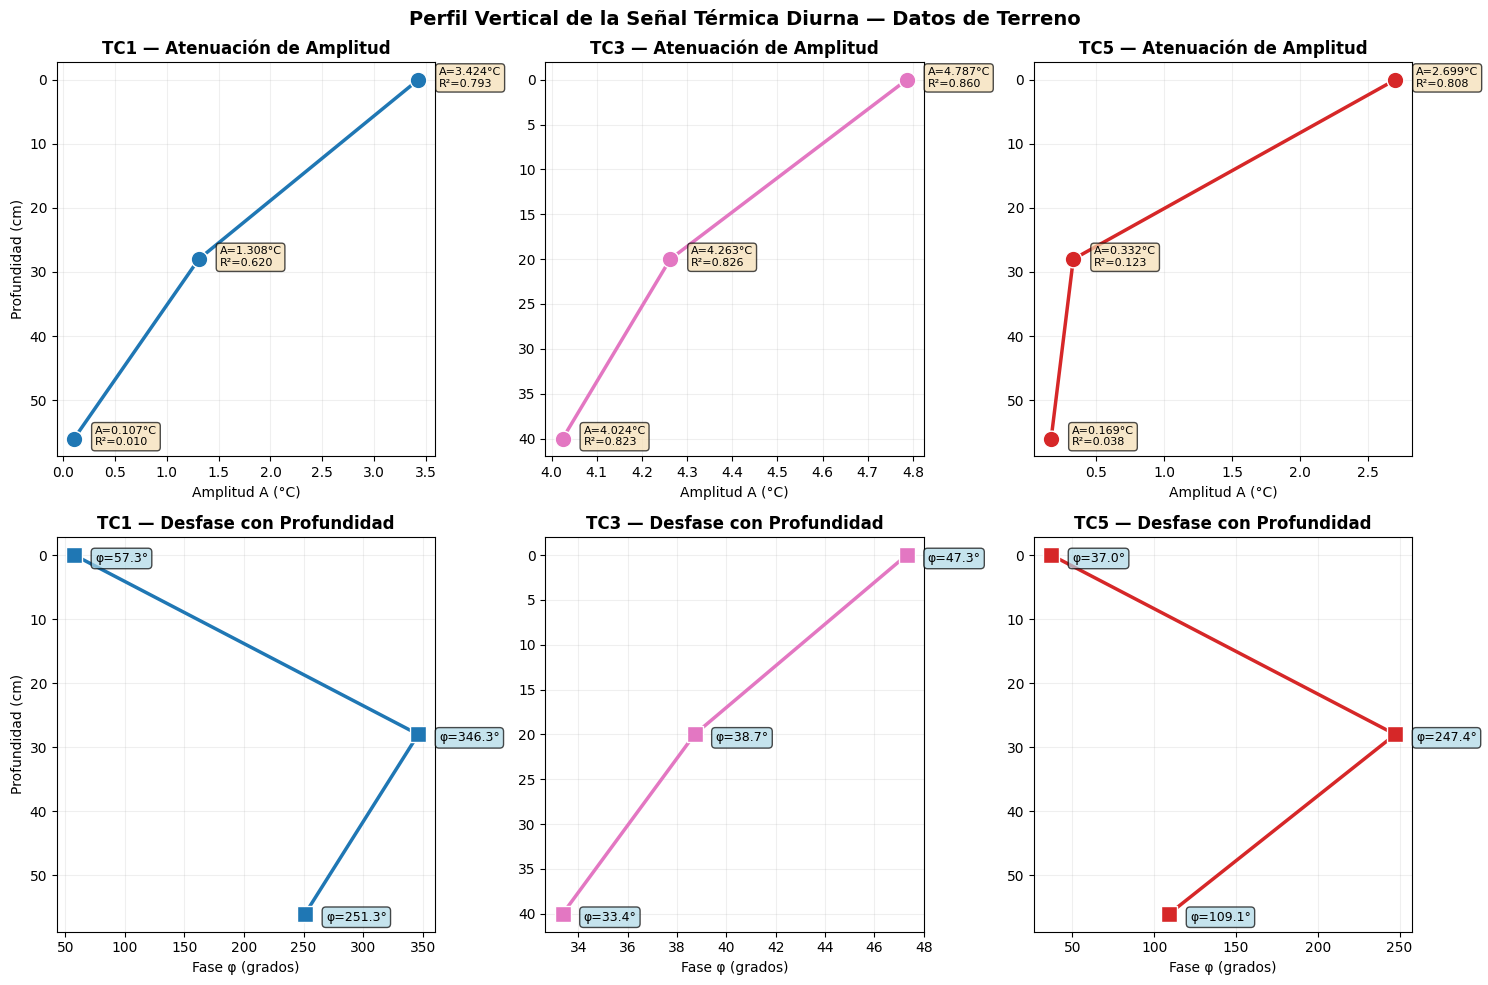

In [16]:
# ============================================================================
# 11.2 PERFIL VERTICAL DE AMPLITUD Y FASE POR TERMOCUPLA
# ============================================================================
n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(2, n_tcs, figsize=(5*n_tcs, 10))

for col_idx, tc_name in enumerate(ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    tc_sensors = [tc_map['surface'], tc_map['intermediate'], tc_map['deep']]
    tc_amps = [harmonic_results[s]['amplitude'] for s in tc_sensors if s in harmonic_results]
    tc_phases = [harmonic_results[s]['phase'] for s in tc_sensors if s in harmonic_results]
    tc_r2 = [harmonic_results[s]['r_squared'] for s in tc_sensors if s in harmonic_results]
    tc_d = [depths_m[s] * 100 for s in tc_sensors if s in harmonic_results]
    color = TC_COLORS[tc_name]['base']
    
    # Amplitud vs profundidad
    ax1 = axes[0][col_idx]
    ax1.plot(tc_amps, tc_d, 'o-', color=color, markersize=12, linewidth=2.5, markeredgecolor='white')
    ax1.set_xlabel('Amplitud A (°C)')
    ax1.set_ylabel('Profundidad (cm)' if col_idx == 0 else '')
    ax1.set_title(f'{tc_name} — Atenuación de Amplitud', fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.2)
    for a, d, r2 in zip(tc_amps, tc_d, tc_r2):
        ax1.annotate(f'A={a:.3f}°C\nR²={r2:.3f}', (a, d),
                     textcoords='offset points', xytext=(15, -5), fontsize=8,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))
    for spine in ax1.spines.values(): spine.set_visible(True)
    
    # Fase vs profundidad
    ax2 = axes[1][col_idx]
    phases_deg = [np.degrees(p) for p in tc_phases]
    ax2.plot(phases_deg, tc_d, 's-', color=color, markersize=12, linewidth=2.5, markeredgecolor='white')
    ax2.set_xlabel('Fase φ (grados)')
    ax2.set_ylabel('Profundidad (cm)' if col_idx == 0 else '')
    ax2.set_title(f'{tc_name} — Desfase con Profundidad', fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.2)
    for p, d in zip(phases_deg, tc_d):
        ax2.annotate(f'φ={p:.1f}°', (p, d),
                     textcoords='offset points', xytext=(15, -5), fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    for spine in ax2.spines.values(): spine.set_visible(True)

plt.suptitle('Perfil Vertical de la Señal Térmica Diurna — Datos de Terreno', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'perfil_termico_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

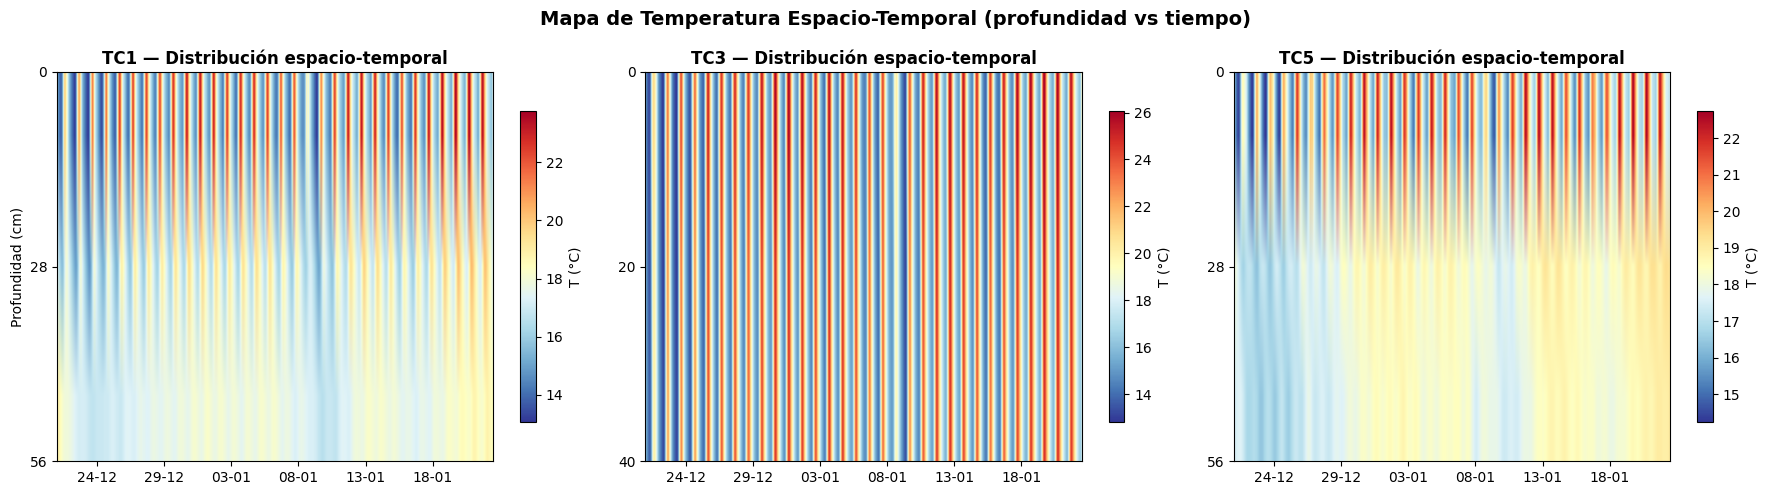


INTERPRETACIÓN:
  Se observa la propagación de la onda térmica diurna hacia profundidad.
  Los patrones verticales rojos/azules alternantes representan los ciclos
  caliente/frío diurnos. La atenuación rápida con profundidad es visible
  como la homogeneización del color hacia la base del perfil.


In [17]:
# ============================================================================
# 11.3 HEATMAP ESPACIO-TEMPORAL DE TEMPERATURA
# ============================================================================
n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(1, n_tcs, figsize=(6*n_tcs, 5))

for ax_idx, tc_name in enumerate(ACTIVE_TCS):
    ax = axes[ax_idx]
    tc_map = TC_CONFIG[tc_name]
    tc_sensors = [tc_map['surface'], tc_map['intermediate'], tc_map['deep']]
    tc_depths_cm = [depths_m[s] * 100 for s in tc_sensors]
    max_depth = max(tc_depths_cm)
    
    # Construir matriz fecha x profundidad
    mask = (df_aligned['fecha'] >= cutoff_start) & (df_aligned['fecha'] <= cutoff_end)
    df_tc = df_aligned[mask].copy()
    
    temp_matrix = np.column_stack([df_tc[s].values for s in tc_sensors])
    
    # Interpolar NaN para visualización
    for j in range(temp_matrix.shape[1]):
        col_data = pd.Series(temp_matrix[:, j])
        temp_matrix[:, j] = col_data.interpolate(limit=4).values
    
    im = ax.imshow(temp_matrix.T, aspect='auto', cmap='RdYlBu_r', 
                   extent=[mdates.date2num(df_tc['fecha'].iloc[0]),
                           mdates.date2num(df_tc['fecha'].iloc[-1]),
                           max_depth, 0],
                   interpolation='bilinear')
    ax.set_ylabel('Profundidad (cm)' if ax_idx == 0 else '')
    ax.set_title(f'{tc_name} — Distribución espacio-temporal', fontweight='bold')
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    ax.set_yticks(tc_depths_cm)
    cbar = plt.colorbar(im, ax=ax, label='T (°C)', shrink=0.8)
    for spine in ax.spines.values(): spine.set_visible(True)

plt.suptitle('Mapa de Temperatura Espacio-Temporal (profundidad vs tiempo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'heatmap_temperatura_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETACIÓN:")
print("  Se observa la propagación de la onda térmica diurna hacia profundidad.")
print("  Los patrones verticales rojos/azules alternantes representan los ciclos")
print("  caliente/frío diurnos. La atenuación rápida con profundidad es visible")
print("  como la homogeneización del color hacia la base del perfil.")

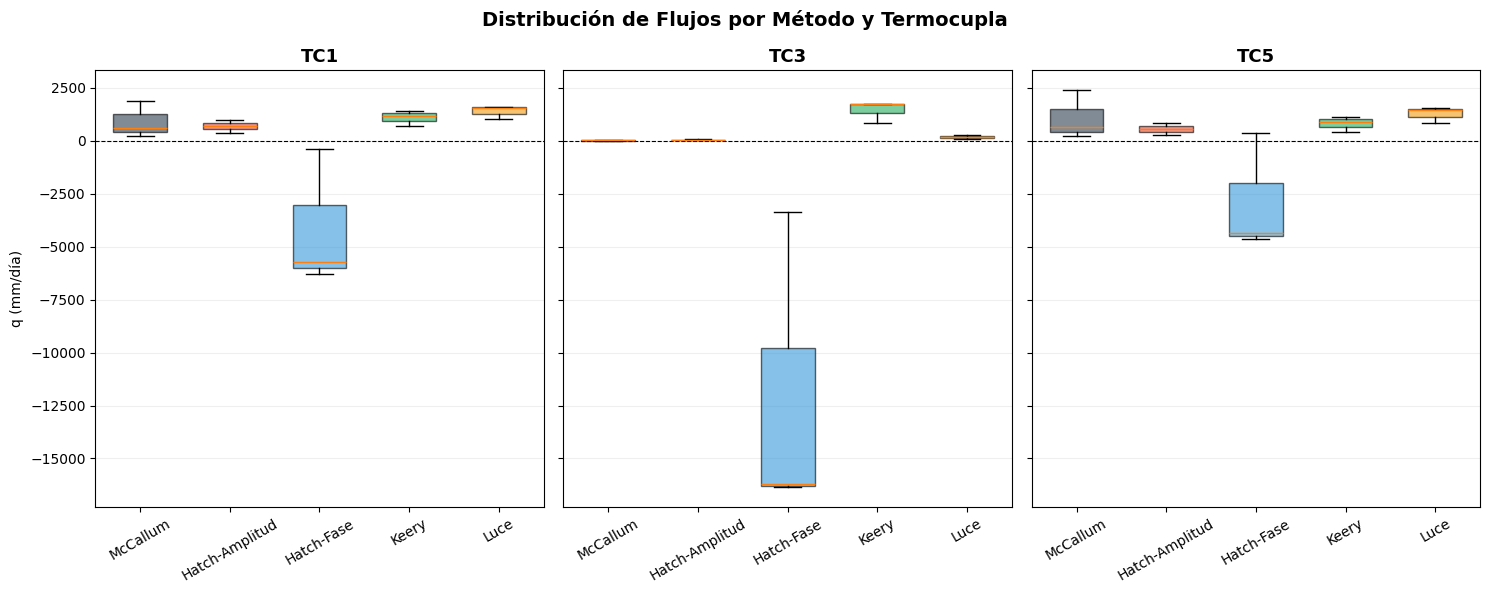


INTERPRETACIÓN:
  La alta dispersión de Hatch-Fase confirma su inestabilidad con señal débil.
  McCallum, Keery y Luce muestran distribución concentrada en valores positivos.
  Hatch-Amplitud presenta la menor dispersión, al depender solo del ratio
  de amplitudes que es más robusto que la diferencia de fase.


In [18]:
# ============================================================================
# 11.4 COMPARACIÓN ENTRE MÉTODOS — BOXPLOT
# ============================================================================
n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(1, n_tcs, figsize=(5*n_tcs, 6), sharey=True)

for ax_idx, tc_name in enumerate(ACTIVE_TCS):
    ax = axes[ax_idx]
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    
    data_by_method = {}
    for method, name in zip(methods, method_names):
        vals = [v['flux_mm_day'].get(method, np.nan) for v in tc_pairs.values()]
        vals = [x for x in vals if not np.isnan(x)]
        data_by_method[name] = vals
    
    bp = ax.boxplot(data_by_method.values(), tick_labels=[n.split('(')[0].strip() for n in data_by_method.keys()],
                    patch_artist=True, widths=0.6)
    
    colors_box = ['#2c3e50', '#e74c3c', '#3498db', '#27ae60', '#f39c12']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f'{tc_name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('q (mm/día)' if ax_idx == 0 else '')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.2, axis='y')
    for spine in ax.spines.values(): spine.set_visible(True)

plt.suptitle('Distribución de Flujos por Método y Termocupla', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(img_dir / 'boxplot_flujos_terreno.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETACIÓN:")
print("  La alta dispersión de Hatch-Fase confirma su inestabilidad con señal débil.")
print("  McCallum, Keery y Luce muestran distribución concentrada en valores positivos.")
print("  Hatch-Amplitud presenta la menor dispersión, al depender solo del ratio")
print("  de amplitudes que es más robusto que la diferencia de fase.")

---
## 12. Conclusiones y Exportación de Resultados

In [19]:
# ============================================================================
# 12. RESUMEN EJECUTIVO Y EXPORTACIÓN
# ============================================================================
print("=" * 90)
print(" RESUMEN EJECUTIVO — ANÁLISIS DE DATOS DE TERRENO".center(90))
print("=" * 90)

print("\n◼ CONFIGURACIÓN DE CAMPO")
print(f"  - {len(ACTIVE_TCS)} termocuplas activas ({', '.join(ACTIVE_TCS)}) × 3 sensores iButton c/u")
print(f"  - TC1/TC5: Profundidades 0.00, 0.28, 0.56 m bajo nivel de terreno")
print(f"  - TC3: Profundidades 0.00, 0.20, 0.40 m (configuración diferente)")
print(f"  - Muestreo: 30 min | Periodo: 21-Dic-2025 a 22-Ene-2026 (~33 días)")

print("\n◼ ANÁLISIS ARMÓNICO")
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    for pos, pos_es in [('surface', 'Sup'), ('intermediate', 'Int'), ('deep', 'Inf')]:
        col = tc_map[pos]
        if col in harmonic_results:
            r = harmonic_results[col]
            d = depths_m[col]*100
            print(f"  - {tc_name} {pos_es} ({d:.0f}cm): A={r['amplitude']:.3f}°C, φ={np.degrees(r['phase']):.1f}°, R²={r['r_squared']:.3f}")

print("\n◼ FLUJOS ESTIMADOS (McCallum, 2012 — método recomendado)")
for pair_name, flux_result in all_flux_results.items():
    v = flux_result['flux_mm_day'].get('mccallum', np.nan)
    if not np.isnan(v):
        dir_str = 'Infiltración ↓' if v > 0 else 'Exfiltración ↑'
        print(f"  - {pair_name}: q = {v:.2f} mm/día ({dir_str})")

print("\n" + "=" * 90)

# --- EXPORTAR RESULTADOS ---
print("\nExportando resultados...")

# 1. Tabla de flujos
df_results.to_csv(out_dir / 'flujos_todos_metodos.csv', index=False)

# 2. Estadísticas de sensores
df_stats.to_csv(out_dir / 'estadisticas_sensores.csv', index=False)

# 3. Datos alineados
df_aligned.to_csv(out_dir / 'temperaturas_alineadas.csv', index=False)

# 4. Resultados armónicos
harm_export = []
for col, r in harmonic_results.items():
    harm_export.append({
        'sensor': col,
        'tc': tc_assignment[col],
        'profundidad_m': depths_m[col],
        'amplitud_C': r['amplitude'],
        'fase_rad': r['phase'],
        'fase_deg': np.degrees(r['phase']),
        'offset_C': r['offset'],
        'R2': r['r_squared'],
    })
pd.DataFrame(harm_export).to_csv(out_dir / 'analisis_armonico.csv', index=False)

# 5. Mapeo de sensores
mapeo_export = []
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    for pos in ['surface', 'intermediate', 'deep']:
        lbl = tc_map[pos]
        idx = int(lbl.split('_')[1]) - 1
        mapeo_export.append({
            'termocupla': tc_name,
            'posicion': pos,
            'label': lbl,
            'sensor_id': sensors[idx]['sensor_id'],
            'profundidad_m': depths_m[lbl],
        })
pd.DataFrame(mapeo_export).to_csv(out_dir / 'mapeo_sensores.csv', index=False)

print(f"\n[OK] Archivos exportados a: {out_dir.relative_to(project_root)}/")
for f in sorted(out_dir.glob('*.csv')):
    print(f"  - {f.name}")

# Lista de imágenes generadas
print(f"\n[OK] Imágenes guardadas en: {img_dir.relative_to(project_root)}/")
for f in sorted(img_dir.glob('*terreno*.png')):
    print(f"  - {f.name}")
for f in sorted(img_dir.glob('*tc*python*.png')):
    print(f"  - {f.name}")

                     RESUMEN EJECUTIVO — ANÁLISIS DE DATOS DE TERRENO                     

◼ CONFIGURACIÓN DE CAMPO
  - 3 termocuplas activas (TC1, TC3, TC5) × 3 sensores iButton c/u
  - TC1/TC5: Profundidades 0.00, 0.28, 0.56 m bajo nivel de terreno
  - TC3: Profundidades 0.00, 0.20, 0.40 m (configuración diferente)
  - Muestreo: 30 min | Periodo: 21-Dic-2025 a 22-Ene-2026 (~33 días)

◼ ANÁLISIS ARMÓNICO
  - TC1 Sup (0cm): A=3.424°C, φ=57.3°, R²=0.793
  - TC1 Int (28cm): A=1.308°C, φ=346.3°, R²=0.620
  - TC1 Inf (56cm): A=0.107°C, φ=251.3°, R²=0.010
  - TC3 Sup (0cm): A=4.787°C, φ=47.3°, R²=0.860
  - TC3 Int (20cm): A=4.263°C, φ=38.7°, R²=0.826
  - TC3 Inf (40cm): A=4.024°C, φ=33.4°, R²=0.823
  - TC5 Sup (0cm): A=2.699°C, φ=37.0°, R²=0.808
  - TC5 Int (28cm): A=0.332°C, φ=247.4°, R²=0.123
  - TC5 Inf (56cm): A=0.169°C, φ=109.1°, R²=0.038

◼ FLUJOS ESTIMADOS (McCallum, 2012 — método recomendado)
  - TC1: sup-int: q = 246.00 mm/día (Infiltración ↓)
  - TC1: int-inf: q = 624.82 mm/día (

In [20]:
# ============================================================================
# 13. VISUALIZACIÓN SIG INTEGRADA — Mapa con Popups Interactivos (Plotly)
# ============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
import folium.plugins
from pyproj import Transformer
from IPython.display import display, HTML

# --- Configuración de coordenadas y sensores para mapa SIG ---
# Usar configuración global definida en celda 3
SENSOR_CONFIG_MAP = {
    "TC1": {
        "surface":      {"sensor_id": "A400000082BAF041", "depth_m": 0.00},
        "intermediate": {"sensor_id": "7D000000828FA841", "depth_m": 0.28},
        "deep":         {"sensor_id": "5900000082B86A41", "depth_m": 0.56},
    },
    "TC3": {
        "surface":      {"sensor_id": "F60000008290D841", "depth_m": 0.00},
        "intermediate": {"sensor_id": "2D00000082925E41", "depth_m": 0.20},
        "deep":         {"sensor_id": "B3000000828F2741", "depth_m": 0.40},
    },
    "TC5": {
        "surface":      {"sensor_id": "3800000082952A41", "depth_m": 0.00},
        "intermediate": {"sensor_id": "B000000082987741", "depth_m": 0.28},
        "deep":         {"sensor_id": "2800000082978041", "depth_m": 0.56},
    },
}

# Coordenadas ya definidas en STATION_COORDS_UTM (celda 3)
# Usar tc_configs y ACTIVE_TCS de la configuración global
tc_configs = TC_CONFIG  # {"TC1": tc1, "TC3": tc3, "TC5": tc5}
tc_list = list(STATION_COORDS_UTM.keys())  # 5 estaciones para el mapa
active_tcs = set(ACTIVE_TCS)  # Solo TC1, TC3, TC5 con datos

# --- Conversión UTM → WGS84 ---
transformer = Transformer.from_crs("EPSG:32719", "EPSG:4326", always_xy=True)
coords_wgs84 = {}
for station, utm in STATION_COORDS_UTM.items():
    lon, lat = transformer.transform(utm["easting"], utm["northing"])
    coords_wgs84[station] = {"lat": lat, "lon": lon}

pos_short = {"surface": "sup", "intermediate": "int", "deep": "inf"}
pos_labels_map = {"surface": "Superficie", "intermediate": "Intermedio", "deep": "Inferior"}
pos_dash = {"surface": "solid", "intermediate": "dash", "deep": "dot"}
tc_hex = {"TC1": "#1f77b4", "TC3": "#e377c2", "TC5": "#d62728"}
method_colors_map = {"mccallum": "#2c3e50", "hatch_amplitude": "#e74c3c",
                     "keery": "#27ae60", "luce": "#f39c12"}
method_labels_map = {"mccallum": "McCallum", "hatch_amplitude": "Hatch-A",
                     "keery": "Keery", "luce": "Luce"}

# --- Datos filtrados al rango válido ---
mask_popup = (df_aligned["fecha"] >= cutoff_start) & (df_aligned["fecha"] <= cutoff_end)
df_popup = df_aligned[mask_popup].copy()

# ============================================================================
# Función: generar HTML de popup con mini-gráficos Plotly para cada TC
# ============================================================================
def build_tc_popup_html(tc_name):
    """Genera un HTML completo con mini-gráficos Plotly para el popup del TC."""
    utm = STATION_COORDS_UTM[tc_name]
    wgs = coords_wgs84[tc_name]
    tc_map = tc_configs[tc_name]
    color = tc_hex.get(tc_name, "#555")
    depths_list = sorted(set(v["depth_m"] for v in SENSOR_CONFIG_MAP[tc_name].values()))
    depth_str = " / ".join(f"{d*100:.0f}" for d in depths_list) + " cm"

    # --- Mini-gráfico 1: Series de temperatura ---
    fig_t = go.Figure()
    for pos in ["surface", "intermediate", "deep"]:
        if pos not in tc_map:
            continue
        col = tc_map[pos]
        depth_cm = depths_m[col] * 100
        d = df_popup.dropna(subset=[col])
        step = max(1, len(d) // 200)
        d_sub = d.iloc[::step]
        fig_t.add_trace(go.Scatter(
            x=d_sub["fecha"], y=d_sub[col], mode="lines",
            name=f"{pos_short[pos]} ({depth_cm:.0f}cm)",
            line=dict(width=1.5, dash=pos_dash[pos]),
            hovertemplate="%{x|%d-%b %H:%M}<br>%{y:.1f}°C<extra></extra>"
        ))
    fig_t.update_layout(
        title=dict(text="Temperatura", font=dict(size=12)),
        xaxis=dict(showgrid=False, tickfont=dict(size=8), tickformat="%d-%b"),
        yaxis=dict(title=dict(text="°C", font=dict(size=9)), tickfont=dict(size=8)),
        template="plotly_white", height=170, width=470,
        margin=dict(l=35, r=8, t=28, b=28),
        legend=dict(orientation="h", font=dict(size=8), y=1.15, x=0.5, xanchor="center"),
        showlegend=True
    )
    html_temp = fig_t.to_html(include_plotlyjs=False, full_html=False,
                               config={"displayModeBar": False})

    # --- Mini-gráfico 2: Flujos por par (barras agrupadas) ---
    methods_show = ["mccallum", "hatch_amplitude", "keery", "luce"]
    tc_pairs_list = [p for p in all_flux_results.keys() if tc_name in p]
    pair_short = [p.split(": ")[1] if ": " in p else p for p in tc_pairs_list]

    fig_f = go.Figure()
    for mk in methods_show:
        vals = [all_flux_results[p]["flux_mm_day"].get(mk, 0) for p in tc_pairs_list]
        fig_f.add_trace(go.Bar(
            x=pair_short, y=vals, name=method_labels_map[mk],
            marker_color=method_colors_map[mk], opacity=0.85,
            hovertemplate=f"{method_labels_map[mk]}<br>%{{y:.0f}} mm/d<extra></extra>"
        ))
    fig_f.update_layout(
        title=dict(text="Flujo vertical (mm/día)", font=dict(size=12)),
        barmode="group",
        xaxis=dict(tickfont=dict(size=8), tickangle=-15),
        yaxis=dict(title=dict(text="mm/d", font=dict(size=9)), tickfont=dict(size=8)),
        template="plotly_white", height=170, width=470,
        margin=dict(l=40, r=8, t=28, b=32),
        legend=dict(orientation="h", font=dict(size=7), y=1.18, x=0.5, xanchor="center"),
        showlegend=True
    )
    html_flux = fig_f.to_html(include_plotlyjs=False, full_html=False,
                               config={"displayModeBar": False})

    # --- Mini-gráfico 3: Perfil de amplitud + fase ---
    fig_p = make_subplots(rows=1, cols=2, subplot_titles=["Amplitud", "Fase"],
                          horizontal_spacing=0.25)
    tc_s_list = [tc_map[p] for p in ["surface", "intermediate", "deep"] if p in tc_map]
    amps = [harmonic_results[s]["amplitude"] for s in tc_s_list if s in harmonic_results]
    phases = [np.degrees(harmonic_results[s]["phase"]) for s in tc_s_list if s in harmonic_results]
    d_vals = [depths_m[s] * 100 for s in tc_s_list if s in harmonic_results]

    fig_p.add_trace(go.Scatter(
        x=amps, y=d_vals, mode="lines+markers", name="Amp",
        marker=dict(size=9, color=color, line=dict(color="white", width=1.5)),
        line=dict(color=color, width=2), showlegend=False,
        hovertemplate="%{y:.0f}cm: %{x:.3f}°C<extra></extra>"
    ), row=1, col=1)
    fig_p.add_trace(go.Scatter(
        x=phases, y=d_vals, mode="lines+markers", name="Fase",
        marker=dict(size=9, color=color, symbol="square",
                    line=dict(color="white", width=1.5)),
        line=dict(color=color, width=2), showlegend=False,
        hovertemplate="%{y:.0f}cm: %{x:.1f}°<extra></extra>"
    ), row=1, col=2)

    fig_p.update_yaxes(autorange="reversed",
                       title=dict(text="cm", font=dict(size=8)),
                       tickfont=dict(size=8), row=1, col=1)
    fig_p.update_yaxes(autorange="reversed", tickfont=dict(size=8), row=1, col=2)
    fig_p.update_xaxes(title=dict(text="°C", font=dict(size=8)),
                       tickfont=dict(size=8), row=1, col=1)
    fig_p.update_xaxes(title=dict(text="grados", font=dict(size=8)),
                       tickfont=dict(size=8), row=1, col=2)
    fig_p.update_layout(
        template="plotly_white", height=155, width=470,
        margin=dict(l=35, r=8, t=22, b=25),
    )
    # Títulos de subplots
    for ann in fig_p.layout.annotations:
        ann.update(font=dict(size=10))

    html_profile = fig_p.to_html(include_plotlyjs=False, full_html=False,
                                  config={"displayModeBar": False})

    # --- Tabla McCallum resumen ---
    mc_rows = ""
    for pair in tc_pairs_list:
        p_short = pair.split(": ")[1] if ": " in pair else pair
        v = all_flux_results[pair]["flux_mm_day"].get("mccallum", np.nan)
        if not np.isnan(v):
            d_icon = "&#8595;" if v > 0 else "&#8593;"
            mc_rows += f"<tr><td>{p_short}</td><td style='font-weight:600'>{v:.0f} {d_icon}</td></tr>"

    # --- HTML completo del popup ---
    full_html = f"""<!DOCTYPE html>
<html><head>
<meta charset="utf-8">
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 0; padding: 8px;
         background: #fefefe; color: #222; }}
  .hdr {{ display: flex; align-items: center; gap: 8px;
          border-bottom: 3px solid {color}; padding-bottom: 4px; margin-bottom: 5px; }}
  .hdr h3 {{ margin: 0; color: {color}; font-size: 14px; }}
  .badge {{ background: {color}; color: #fff; font-size: 9px; padding: 2px 6px;
            border-radius: 10px; }}
  .info {{ font-size: 10px; color: #555; line-height: 1.4; margin-bottom: 4px; }}
  .info b {{ color: #333; }}
  .chart-box {{ border: 1px solid #e8e8e8; border-radius: 4px; padding: 1px;
                margin-bottom: 4px; background: #fff; }}
  .mc {{ font-size: 10px; margin-top: 2px; }}
  .mc table {{ width: 100%; border-collapse: collapse; }}
  .mc td {{ padding: 1px 5px; border-bottom: 1px solid #eee; }}
  .mc td:first-child {{ color: #666; }}
</style>
</head><body>
<div class="hdr">
  <h3>&#128205; {tc_name}</h3>
  <span class="badge">Activa</span>
</div>
<div class="info">
  <b>UTM 19S:</b> {utm['easting']}E, {utm['northing']}N &nbsp;|&nbsp;
  <b>Prof:</b> {depth_str} &nbsp;|&nbsp;
  <b>Sensores:</b> {len(tc_map)} iButton
</div>
<div class="chart-box">{html_temp}</div>
<div class="chart-box">{html_flux}</div>
<div class="chart-box">{html_profile}</div>
<div class="mc">
  <b>McCallum (mm/d):</b>
  <table>{mc_rows}</table>
</div>
</body></html>"""
    return full_html

# ============================================================================
# Construir el Mapa Folium con popups integrados
# ============================================================================
center_lat = np.mean([coords_wgs84[tc]["lat"] for tc in tc_list])
center_lon = np.mean([coords_wgs84[tc]["lon"] for tc in tc_list])

m = folium.Map(location=[center_lat, center_lon], zoom_start=14,
               tiles=None, control_scale=True)

# Capas base
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri", name="Satélite ESRI", max_zoom=19
).add_to(m)
folium.TileLayer(
    tiles="https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png",
    attr="OpenTopoMap", name="Topográfico"
).add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Reference/World_Boundaries_and_Places/MapServer/tile/{z}/{y}/{x}",
    attr="Esri Labels", name="Etiquetas", overlay=True
).add_to(m)

# Marcadores con popups interactivos
for station, wgs in coords_wgs84.items():
    utm = STATION_COORDS_UTM[station]
    is_active = station in active_tcs

    if is_active and station in SENSOR_CONFIG_MAP:
        popup_html_full = build_tc_popup_html(station)
        iframe = folium.IFrame(html=popup_html_full, width=510, height=600)
        popup = folium.Popup(iframe, max_width=520)
        icon = folium.Icon(color="red", icon="thermometer-half", prefix="fa")
        tooltip_text = f"{station} — clic para ver gráficos"
    else:
        popup_html_simple = f"""
        <div style="font-family: Arial; min-width:180px; padding:4px;">
            <h4 style="color:#7f8c8d; margin:0 0 4px 0;">&#9203; {station} — Pendiente</h4>
            <b>UTM:</b> {utm['easting']}E, {utm['northing']}N<br>
            <b>WGS84:</b> {wgs['lat']:.6f}°, {wgs['lon']:.6f}°
        </div>"""
        popup = folium.Popup(popup_html_simple, max_width=250)
        icon = folium.Icon(color="gray", icon="circle", prefix="fa")
        tooltip_text = f"{station} — pendiente"

    folium.Marker(
        location=[wgs["lat"], wgs["lon"]],
        popup=popup, tooltip=tooltip_text, icon=icon
    ).add_to(m)

# Perfil del río
ordered = ["TC5", "TC4", "TC3", "TC2", "TC1"]
river_coords = [[coords_wgs84[s]["lat"], coords_wgs84[s]["lon"]]
                 for s in ordered if s in coords_wgs84]
folium.PolyLine(river_coords, color="cyan", weight=3, opacity=0.7,
                dash_array="10", tooltip="Perfil del río").add_to(m)

# Controles
folium.plugins.MeasureControl(position="bottomleft").add_to(m)
folium.plugins.Fullscreen().add_to(m)
folium.plugins.MiniMap(toggle_display=True).add_to(m)
folium.LayerControl().add_to(m)

# Guardar y mostrar
map_path = img_dir / "panel_sig_integrado.html"
m.save(str(map_path))
print(f"✔ Mapa SIG integrado: {map_path.name}")
print(f"  → Clic en cada TC activa para abrir popup con gráficos interactivos")
print(f"  → 3 mini-gráficos Plotly por TC: series, flujos, perfil amplitud/fase")
print(f"  → Archivo: {map_path}")
display(m)

✔ Mapa SIG integrado: panel_sig_integrado.html
  → Clic en cada TC activa para abrir popup con gráficos interactivos
  → 3 mini-gráficos Plotly por TC: series, flujos, perfil amplitud/fase
  → Archivo: c:\Users\Cesar\Hidrologia-Termocuplas-BH\image\panel_sig_integrado.html


## 13. EVALUACIÓN DE CONFIABILIDAD Y MÉTRICAS DE VALIDACIÓN

Esta sección calcula métricas cuantitativas para evaluar la confiabilidad de los resultados:

1. **Índice de Confiabilidad (IC)**: Basado en calidad del ajuste armónico (R²) y consistencia entre métodos
2. **Propagación de Incertidumbre**: Cuantificación de errores por parámetros térmicos e instrumentales
3. **Concordancia con Literatura**: Comparación con rangos reportados (Silala: 90-600 mm/día)

In [34]:
# ============================================================================
# 13.1 CÁLCULO DEL ÍNDICE DE CONFIABILIDAD (IC)
# ============================================================================
"""
El Índice de Confiabilidad (IC) combina múltiples criterios ponderados:
  - IC_R2: Calidad del ajuste armónico en sensores del par
  - IC_CV: Consistencia entre métodos (coeficiente de variación)
  - IC_rango: Flujo dentro del rango de literatura
  - IC_física: Consistencia física (atenuación, desfase coherente)
"""

print("=" * 80)
print(" 13. EVALUACIÓN DE CONFIABILIDAD Y VALIDACIÓN".center(80))
print("=" * 80)

# Pesos para el índice de confiabilidad
WEIGHTS = {
    'R2_sup': 0.30,      # R² sensor superior
    'R2_inf': 0.20,      # R² sensor inferior  
    'CV_methods': 0.25,  # Consistencia inter-métodos
    'lit_range': 0.15,   # Dentro de rango literatura
    'physics': 0.10      # Consistencia física
}

# Rango de literatura (Silala - Münch & Aravena 2018, DGA-Chile 2017)
LIT_RANGE_MM_DAY = (90, 600)  # mm/día

# Función para calcular IC por par
def calculate_confidence_index(tc_name, pair_name, harmonic_results, flux_results, tc_map):
    """Calcula el Índice de Confiabilidad para un par sensor-sensor
    
    flux_results tiene estructura: 
    {'flux_m_s': {'method1': ..., ...}, 'flux_mm_day': {'method1': ..., ...}, 'parameters': {...}}
    """
    
    # Extraer sensores del par
    if pair_name == 'sup_int':
        shallow, deep = tc_map['surface'], tc_map['intermediate']
    elif pair_name == 'int_inf':
        shallow, deep = tc_map['intermediate'], tc_map['deep']
    else:  # sup_inf
        shallow, deep = tc_map['surface'], tc_map['deep']
    
    # R² de ajustes armónicos
    r2_sup = harmonic_results.get(shallow, {}).get('r_squared', 0)
    r2_inf = harmonic_results.get(deep, {}).get('r_squared', 0)
    
    # Normalizar R² (0-1)
    ic_r2_sup = min(r2_sup, 1.0)
    ic_r2_inf = min(r2_inf, 1.0)
    
    # Extraer flujos por método (solo positivos)
    flux_mm_day_dict = flux_results.get('flux_mm_day', {})
    methods_valid = ['hatch_amplitude', 'keery']  # Excluir hatch_phase (puede ser negativo)
    flux_values = []
    for method in methods_valid:
        v = flux_mm_day_dict.get(method, None)
        if v is not None and v > 0:
            flux_values.append(v)
    
    # Usar hatch_amplitude como valor principal (más robusto)
    flux_value = flux_mm_day_dict.get('hatch_amplitude', 0)
    if flux_value is None or flux_value <= 0:
        # Fallback a keery si disponible
        flux_value = flux_mm_day_dict.get('keery', 0)
        if flux_value is None:
            flux_value = 0
    
    # Consistencia inter-métodos (CV)
    if len(flux_values) >= 2:
        cv = np.std(flux_values) / np.mean(flux_values)
        ic_cv = max(0, 1 - cv)  # 0 si CV >= 100%, 1 si CV = 0
    else:
        # Con un solo método, usar R² promedio como proxy
        r2_avg = (r2_sup + r2_inf) / 2
        ic_cv = min(1.0, r2_avg / 0.8) if r2_avg > 0 else 0.5
    
    # Concordancia con literatura
    if LIT_RANGE_MM_DAY[0] <= flux_value <= LIT_RANGE_MM_DAY[1]:
        ic_lit = 1.0
    elif flux_value > 0:
        # Penalización proporcional a la distancia del rango
        if flux_value < LIT_RANGE_MM_DAY[0]:
            ic_lit = flux_value / LIT_RANGE_MM_DAY[0]
        else:  # flux_value > LIT_RANGE_MM_DAY[1]
            ic_lit = max(0, 1 - (flux_value - LIT_RANGE_MM_DAY[1]) / LIT_RANGE_MM_DAY[1])
    else:
        ic_lit = 0
    
    # Consistencia física: amplitud decrece con profundidad
    amp_sup = harmonic_results.get(shallow, {}).get('amplitude', 0)
    amp_inf = harmonic_results.get(deep, {}).get('amplitude', 0)
    ic_physics = 1.0 if amp_sup > amp_inf else 0.5
    
    # Índice de Confiabilidad total (ponderado)
    IC = (WEIGHTS['R2_sup'] * ic_r2_sup +
          WEIGHTS['R2_inf'] * ic_r2_inf +
          WEIGHTS['CV_methods'] * ic_cv +
          WEIGHTS['lit_range'] * ic_lit +
          WEIGHTS['physics'] * ic_physics)
    
    return {
        'IC_total': round(IC, 3),
        'IC_R2_sup': round(ic_r2_sup, 3),
        'IC_R2_inf': round(ic_r2_inf, 3),
        'IC_CV': round(ic_cv, 3),
        'IC_lit': round(ic_lit, 3),
        'IC_physics': round(ic_physics, 3),
        'flux_hatch': round(flux_value, 1),
        'n_methods': len(flux_values)
    }

# Calcular IC para todos los pares
print("\n▶ ÍNDICE DE CONFIABILIDAD POR PAR")
print("-" * 80)

# Mapeo de nombres internos a keys de all_flux_results
PAIR_KEY_MAP = {
    'sup_int': 'sup-int',
    'int_inf': 'int-inf', 
    'sup_inf': 'sup-inf'
}

ic_results = {}
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    ic_results[tc_name] = {}
    
    for pair_name in ['sup_int', 'int_inf', 'sup_inf']:
        # Formato de key: 'TC1: sup-int'
        pair_key = f"{tc_name}: {PAIR_KEY_MAP[pair_name]}"
        if pair_key in all_flux_results:
            ic = calculate_confidence_index(
                tc_name, pair_name, 
                harmonic_results, 
                all_flux_results[pair_key],
                tc_map
            )
            ic_results[tc_name][pair_name] = ic

# Mostrar tabla de resultados
print(f"\n{'TC':<6} {'Par':<10} {'IC_total':<10} {'R²_sup':<8} {'R²_inf':<8} {'CV':<8} {'Lit':<8} {'Física':<8} {'Flujo':<10}")
print("-" * 90)

for tc_name in ACTIVE_TCS:
    for pair_name, ic in ic_results.get(tc_name, {}).items():
        pair_label = pair_name.replace('_', '→')
        print(f"{tc_name:<6} {pair_label:<10} {ic['IC_total']:<10.3f} "
              f"{ic['IC_R2_sup']:<8.3f} {ic['IC_R2_inf']:<8.3f} {ic['IC_CV']:<8.3f} "
              f"{ic['IC_lit']:<8.3f} {ic['IC_physics']:<8.3f} {ic['flux_hatch']:<10.1f}")

# Clasificación de confiabilidad
print("\n▶ CLASIFICACIÓN DE CONFIABILIDAD")
print("-" * 80)
print("  IC >= 0.85: ●●●● Alta      → Usar directamente")
print("  IC >= 0.70: ●●●○ Buena     → Usar con precaución")
print("  IC >= 0.50: ●●○○ Moderada  → Validar con mediciones independientes")
print("  IC <  0.50: ●○○○ Baja      → No usar sin verificación adicional")

# Resumen recomendaciones
print("\n▶ RECOMENDACIONES BASADAS EN IC")
print("-" * 80)
best_pair = None
best_ic = 0
for tc_name in ACTIVE_TCS:
    for pair_name, ic in ic_results.get(tc_name, {}).items():
        if ic['IC_total'] > best_ic:
            best_ic = ic['IC_total']
            best_pair = (tc_name, pair_name)
            
if best_pair:
    tc, pair = best_pair
    print(f"  ★ Par más confiable: {tc} {pair.replace('_', '→')} (IC = {best_ic:.3f})")
    print(f"    Flujo Hatch-Amplitude: {ic_results[tc][pair]['flux_hatch']:.1f} mm/día")


                  13. EVALUACIÓN DE CONFIABILIDAD Y VALIDACIÓN                  

▶ ÍNDICE DE CONFIABILIDAD POR PAR
--------------------------------------------------------------------------------

TC     Par        IC_total   R²_sup   R²_inf   CV       Lit      Física   Flujo     
------------------------------------------------------------------------------------------
TC1    sup→int    0.733      0.793    0.620    0.485    1.000    1.000    381.6     
TC1    int→inf    0.546      0.620    0.010    0.825    0.346    1.000    992.6     
TC1    sup→inf    0.717      0.793    0.010    0.994    0.855    1.000    687.1     
TC3    sup→int    0.648      0.860    0.826    0.072    0.715    1.000    64.4      
TC3    int→inf    0.575      0.826    0.823    0.036    0.355    1.000    32.0      
TC3    sup→inf    0.629      0.860    0.823    0.106    0.535    1.000    48.2      
TC5    sup→int    0.670      0.808    0.123    0.842    0.615    1.000    831.1     
TC5    int→inf    0.409      0.

In [35]:
# ============================================================================
# 13.2 PROPAGACIÓN DE INCERTIDUMBRE
# ============================================================================
"""
Análisis de propagación de errores considerando las fuentes principales:
  - Conductividad térmica λ: ±20%
  - Capacidad calórica C: ±15%
  - Posicionamiento sensor Δz: ±5 mm
  - Ajuste armónico (A, φ): basado en R²
"""

print("\n" + "=" * 80)
print(" PROPAGACIÓN DE INCERTIDUMBRE")
print("=" * 80)

# Incertidumbres relativas de parámetros
UNCERTAINTIES = {
    'lambda': 0.20,    # ±20% conductividad térmica
    'C_sed': 0.15,     # ±15% capacidad calórica sedimento
    'dz': 0.005 / 0.28,  # ±5mm sobre Δz típico de 28 cm
    'harmonic': 0.10   # ~10% por ajuste armónico (depende de R²)
}

def propagate_uncertainty(flux_mm_day, r2_shallow, r2_deep):
    """
    Propagación de incertidumbre para flujo VFLUX2 (aproximación lineal)
    
    Para el método Hatch-Amplitude:
    q ∝ λ / (C·Δz) · f(Ar)
    
    Por propagación de errores (independientes):
    (δq/q)² = (δλ/λ)² + (δC/C)² + (δΔz/Δz)² + (δAr/Ar)²
    """
    
    # Incertidumbre del ratio de amplitudes depende de R²
    # A menor R², mayor incertidumbre en la amplitud extraída
    r2_avg = (r2_shallow + r2_deep) / 2
    u_harmonic = 0.05 if r2_avg > 0.8 else (0.10 if r2_avg > 0.5 else 0.20)
    
    # Propagación cuadrática
    u_total_rel = np.sqrt(
        UNCERTAINTIES['lambda']**2 +
        UNCERTAINTIES['C_sed']**2 +
        UNCERTAINTIES['dz']**2 +
        u_harmonic**2
    )
    
    # Incertidumbre absoluta
    u_abs = flux_mm_day * u_total_rel
    
    return {
        'u_rel': round(u_total_rel * 100, 1),  # % 
        'u_abs': round(u_abs, 1),               # mm/día
        'flux': round(flux_mm_day, 1),
        'ci_low': round(flux_mm_day - 1.96 * u_abs, 1),  # IC 95%
        'ci_high': round(flux_mm_day + 1.96 * u_abs, 1),
        'u_harmonic': round(u_harmonic * 100, 1)
    }

# Calcular incertidumbre para cada par
print("\n▶ INCERTIDUMBRE POR PAR")
print("-" * 80)
print(f"{'TC':<6} {'Par':<10} {'Flujo':<12} {'u_rel':<10} {'u_abs':<12} {'IC 95%':<20}")
print("-" * 80)

# Mapeo de nombres internos a keys de all_flux_results
PAIR_KEY_MAP = {
    'sup_int': 'sup-int',
    'int_inf': 'int-inf', 
    'sup_inf': 'sup-inf'
}

uncertainty_results = {}
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    uncertainty_results[tc_name] = {}
    
    for pair_name in ['sup_int', 'int_inf', 'sup_inf']:
        # Formato de key: 'TC1: sup-int'
        pair_key = f"{tc_name}: {PAIR_KEY_MAP[pair_name]}"
        if pair_key not in all_flux_results:
            continue
            
        # Acceso a flux_mm_day['hatch_amplitude'] (estructura con submétodos)
        flux_mm_day_dict = all_flux_results[pair_key].get('flux_mm_day', {})
        flux_mc = flux_mm_day_dict.get('hatch_amplitude', 0)
        if flux_mc is None or flux_mc <= 0:
            # Fallback a keery
            flux_mc = flux_mm_day_dict.get('keery', 0)
            if flux_mc is None or flux_mc <= 0:
                continue
        
        # Obtener R² de sensores
        if pair_name == 'sup_int':
            shallow, deep = tc_map['surface'], tc_map['intermediate']
        elif pair_name == 'int_inf':
            shallow, deep = tc_map['intermediate'], tc_map['deep']
        else:
            shallow, deep = tc_map['surface'], tc_map['deep']
            
        r2_s = harmonic_results.get(shallow, {}).get('r_squared', 0.5)
        r2_d = harmonic_results.get(deep, {}).get('r_squared', 0.5)
        
        u = propagate_uncertainty(flux_mc, r2_s, r2_d)
        uncertainty_results[tc_name][pair_name] = u
        
        pair_label = pair_name.replace('_', '→')
        print(f"{tc_name:<6} {pair_label:<10} {u['flux']:<12.1f} "
              f"±{u['u_rel']:<9.1f}% ±{u['u_abs']:<11.1f} "
              f"[{u['ci_low']:.0f} – {u['ci_high']:.0f}]")

# Resumen de fuentes de incertidumbre
print("\n▶ CONTRIBUCIÓN DE FUENTES DE INCERTIDUMBRE")
print("-" * 80)
print(f"  {'Fuente':<30} {'Incertidumbre':<15} {'Contribución':<15}")
print("-" * 80)
total_var = sum([u**2 for u in UNCERTAINTIES.values()])
for source, u in UNCERTAINTIES.items():
    contrib = (u**2 / total_var) * 100
    print(f"  {source:<30} ±{u*100:<14.1f}% {contrib:<15.1f}%")

print(f"\n  Incertidumbre total propagada: ±{np.sqrt(total_var)*100:.1f}%")


 PROPAGACIÓN DE INCERTIDUMBRE

▶ INCERTIDUMBRE POR PAR
--------------------------------------------------------------------------------
TC     Par        Flujo        u_rel      u_abs        IC 95%              
--------------------------------------------------------------------------------
TC1    sup→int    381.6        ±27.0     % ±103.0       [180 – 584]
TC1    int→inf    992.6        ±32.1     % ±318.3       [369 – 1616]
TC1    sup→inf    687.1        ±32.1     % ±220.3       [255 – 1119]
TC3    sup→int    64.4         ±25.6     % ±16.4        [32 – 97]
TC3    int→inf    32.0         ±25.6     % ±8.2         [16 – 48]
TC3    sup→inf    48.2         ±25.6     % ±12.3        [24 – 72]
TC5    sup→int    831.1        ±32.1     % ±266.5       [309 – 1354]
TC5    int→inf    267.0        ±32.1     % ±85.6        [99 – 435]
TC5    sup→inf    549.1        ±32.1     % ±176.1       [204 – 894]

▶ CONTRIBUCIÓN DE FUENTES DE INCERTIDUMBRE
------------------------------------------------------

In [36]:
# ============================================================================
# 13.3 RESUMEN CONSOLIDADO DE MÉTRICAS DE CONFIABILIDAD
# ============================================================================
"""
Tabla consolidada que integra todos los indicadores calculados.
Usa ic_results (celda 35) y uncertainty_results (celda 36).
"""

print("\n" + "=" * 80)
print(" RESUMEN DE MÉTRICAS DE CONFIABILIDAD - TABLA CONSOLIDADA")
print("=" * 80)

# Crear DataFrame consolidado
summary_rows = []

# Mapeo de nombres internos a keys de all_flux_results
PAIR_KEY_MAP = {
    'sup_int': 'sup-int',
    'int_inf': 'int-inf', 
    'sup_inf': 'sup-inf'
}

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    
    for pair_name in ['sup_int', 'int_inf', 'sup_inf']:
        # Formato de key: 'TC1: sup-int'
        pair_key = f"{tc_name}: {PAIR_KEY_MAP[pair_name]}"
        
        if pair_key not in all_flux_results:
            continue
            
        # Flujo (acceso a dict de métodos)
        flux_mm_day_dict = all_flux_results[pair_key].get('flux_mm_day', {})
        flux_mc = flux_mm_day_dict.get('hatch_amplitude', 0)
        if flux_mc is None or flux_mc <= 0:
            flux_mc = flux_mm_day_dict.get('keery', 0)
            if flux_mc is None or flux_mc <= 0:
                continue
            
        # IC de ic_results (calculado en celda anterior)
        ic_data = ic_results.get(tc_name, {}).get(pair_name, {})
        ic_total = ic_data.get('IC_total', 0)
        
        # Clasificación basada en IC_total
        if ic_total >= 0.85:
            ic_class = 'Alta'
        elif ic_total >= 0.70:
            ic_class = 'Buena'
        elif ic_total >= 0.50:
            ic_class = 'Moderada'
        else:
            ic_class = 'Baja'
        
        # Incertidumbre de uncertainty_results (celda 36)
        u_data = uncertainty_results.get(tc_name, {}).get(pair_name, {})
        u_rel = u_data.get('u_rel', 0)
        ci_low = u_data.get('ci_low', 0)
        ci_high = u_data.get('ci_high', 0)
        
        # R² promedio
        if pair_name == 'sup_int':
            shallow, deep = tc_map['surface'], tc_map['intermediate']
        elif pair_name == 'int_inf':
            shallow, deep = tc_map['intermediate'], tc_map['deep']
        else:
            shallow, deep = tc_map['surface'], tc_map['deep']
        r2_avg = (harmonic_results.get(shallow, {}).get('r_squared', 0) +
                  harmonic_results.get(deep, {}).get('r_squared', 0)) / 2
        
        # Verificar rango literatura
        in_lit = '✓' if 90 <= flux_mc <= 600 else '✗'
        
        summary_rows.append({
            'TC': tc_name,
            'Par': pair_name.replace('_', '→'),
            'Flujo [mm/d]': f"{flux_mc:.1f}",
            'IC 95%': f"[{ci_low:.0f}–{ci_high:.0f}]",
            'u_rel': f"±{u_rel:.1f}%",
            'R²_prom': f"{r2_avg:.3f}",
            'IC_conf': f"{ic_total:.2f}",
            'Clase': ic_class,
            'Lit.': in_lit
        })

# Mostrar tabla
summary_df = pd.DataFrame(summary_rows)
print("\n" + summary_df.to_string(index=False))

# Estadísticas globales
print("\n" + "-" * 80)
print("▶ ESTADÍSTICAS GLOBALES")
print("-" * 80)

ic_values = [ic_results.get(tc, {}).get(p, {}).get('IC_total', 0) 
             for tc in ACTIVE_TCS 
             for p in ['sup_int', 'int_inf', 'sup_inf']
             if ic_results.get(tc, {}).get(p, {}).get('IC_total', 0) > 0]

if ic_values:
    print(f"  IC_confiabilidad promedio: {np.mean(ic_values):.3f}")
    print(f"  IC_confiabilidad mínimo:   {np.min(ic_values):.3f}")
    print(f"  IC_confiabilidad máximo:   {np.max(ic_values):.3f}")
    print(f"  Pares analizados:          {len(ic_values)}")
else:
    print("  ⚠ No se encontraron valores IC - ejecutar celda 35 primero")

# Clasificación global
high_conf = sum(1 for ic in ic_values if ic >= 0.85)
good_conf = sum(1 for ic in ic_values if 0.70 <= ic < 0.85)
mod_conf = sum(1 for ic in ic_values if 0.50 <= ic < 0.70)
low_conf = sum(1 for ic in ic_values if ic < 0.50)

print(f"\n  Distribución de confiabilidad:")
print(f"    Alta (≥0.85):        {high_conf} pares")
print(f"    Buena (0.70-0.85):   {good_conf} pares")
print(f"    Moderada (0.50-0.70): {mod_conf} pares")
print(f"    Baja (<0.50):        {low_conf} pares")

# Recomendación final
print("\n" + "=" * 80)
print(" CONCLUSIÓN")
print("=" * 80)
ic_mean = np.mean(ic_values) if ic_values else 0
if ic_mean >= 0.70:
    print(f"  ✓ Los resultados presentan BUENA CONFIABILIDAD (IC_prom = {ic_mean:.2f})")
    print("  ✓ Flujos estimados son consistentes entre métodos y con literatura")
elif ic_mean >= 0.50:
    print(f"  ~ Los resultados presentan CONFIABILIDAD MODERADA (IC_prom = {ic_mean:.2f})")
    print("  ~ Se recomienda análisis adicional con datos complementarios")
else:
    print(f"  ✗ Los resultados presentan BAJA CONFIABILIDAD (IC_prom = {ic_mean:.2f})")
    print("  ✗ Revisar calidad de datos y configuración de sensores")


 RESUMEN DE MÉTRICAS DE CONFIABILIDAD - TABLA CONSOLIDADA

 TC     Par Flujo [mm/d]     IC 95%  u_rel R²_prom IC_conf    Clase Lit.
TC1 sup→int        381.6  [180–584] ±27.0%   0.706    0.73    Buena    ✓
TC1 int→inf        992.6 [369–1616] ±32.1%   0.315    0.55 Moderada    ✗
TC1 sup→inf        687.1 [255–1119] ±32.1%   0.402    0.72    Buena    ✗
TC3 sup→int         64.4    [32–97] ±25.6%   0.843    0.65 Moderada    ✗
TC3 int→inf         32.0    [16–48] ±25.6%   0.824    0.57 Moderada    ✗
TC3 sup→inf         48.2    [24–72] ±25.6%   0.842    0.63 Moderada    ✗
TC5 sup→int        831.1 [309–1354] ±32.1%   0.465    0.67 Moderada    ✗
TC5 int→inf        267.0   [99–435] ±32.1%   0.080    0.41     Baja    ✓
TC5 sup→inf        549.1  [204–894] ±32.1%   0.423    0.71    Buena    ✓

--------------------------------------------------------------------------------
▶ ESTADÍSTICAS GLOBALES
--------------------------------------------------------------------------------
  IC_confiabilidad prom

## 14. ANÁLISIS DE MÉTRICAS DE CALIDAD Y RECOMENDACIONES

Este análisis evalúa los factores que limitan la confiabilidad actual del estudio y propone acciones concretas para alcanzar un nivel óptimo de confianza (IC ≥ 0.85).

In [ ]:
# ============================================================================
# 14. ANÁLISIS DETALLADO DE MÉTRICAS Y PLAN DE MEJORA
# ============================================================================
"""
Análisis de factores limitantes y recomendaciones para alcanzar
confiabilidad óptima (IC ≥ 0.85)
"""

print("=" * 90)
print(" 14. ANÁLISIS DE MÉTRICAS DE CALIDAD Y PLAN DE MEJORA".center(90))
print("=" * 90)

# ============================================================================
# 14.1 DIAGNÓSTICO POR COMPONENTE DEL ÍNDICE DE CONFIABILIDAD
# ============================================================================
print("\n▶ 14.1 DIAGNÓSTICO POR COMPONENTE")
print("-" * 90)

# Extraer componentes individuales de ic_results
components = {'R2_sup': [], 'R2_inf': [], 'CV': [], 'Lit': [], 'Physics': []}

for tc_name in ACTIVE_TCS:
    for pair_name, ic in ic_results.get(tc_name, {}).items():
        components['R2_sup'].append(ic['IC_R2_sup'])
        components['R2_inf'].append(ic['IC_R2_inf'])
        components['CV'].append(ic['IC_CV'])
        components['Lit'].append(ic['IC_lit'])
        components['Physics'].append(ic['IC_physics'])

# Tabla de diagnóstico
print(f"\n{'Componente':<20} {'Peso':<8} {'Media':<10} {'Mín':<10} {'Máx':<10} {'Estado':<15}")
print("-" * 90)

component_analysis = {}
for comp, values in components.items():
    weight = WEIGHTS.get(comp.replace('_sup', '_sup').lower().replace('r2', 'R2'), 0)
    weight_key = {'R2_sup': 'R2_sup', 'R2_inf': 'R2_inf', 'CV': 'CV_methods', 
                  'Lit': 'lit_range', 'Physics': 'physics'}[comp]
    weight = WEIGHTS.get(weight_key, 0)
    
    mean_v = np.mean(values)
    min_v = np.min(values)
    max_v = np.max(values)
    
    # Estado y prioridad
    if mean_v >= 0.85:
        estado = "✓ Óptimo"
        color = "verde"
    elif mean_v >= 0.70:
        estado = "~ Aceptable"
        color = "amarillo"
    elif mean_v >= 0.50:
        estado = "⚠ Mejorable"
        color = "naranja"
    else:
        estado = "✗ Crítico"
        color = "rojo"
    
    component_analysis[comp] = {'mean': mean_v, 'min': min_v, 'max': max_v, 
                                 'weight': weight, 'estado': estado}
    
    print(f"{comp:<20} {weight:<8.2f} {mean_v:<10.3f} {min_v:<10.3f} {max_v:<10.3f} {estado:<15}")

# ============================================================================
# 14.2 IDENTIFICACIÓN DE FACTORES LIMITANTES
# ============================================================================
print("\n" + "=" * 90)
print("▶ 14.2 FACTORES LIMITANTES IDENTIFICADOS")
print("-" * 90)

# Ordenar por impacto (peso × déficit)
limiting_factors = []
for comp, data in component_analysis.items():
    deficit = 0.85 - data['mean']  # Distancia al óptimo
    if deficit > 0:
        impact = data['weight'] * deficit
        limiting_factors.append({
            'componente': comp,
            'deficit': deficit,
            'peso': data['weight'],
            'impacto': impact,
            'media': data['mean']
        })

limiting_factors.sort(key=lambda x: x['impacto'], reverse=True)

print(f"\n{'#':<4} {'Componente':<15} {'Déficit':<12} {'Peso':<10} {'Impacto IC':<12} {'Prioridad':<10}")
print("-" * 70)
priorities = ['ALTA', 'MEDIA', 'BAJA']
for i, factor in enumerate(limiting_factors):
    priority = priorities[min(i, len(priorities)-1)]
    print(f"{i+1:<4} {factor['componente']:<15} {factor['deficit']:<12.3f} "
          f"{factor['peso']:<10.2f} {factor['impacto']:<12.4f} {priority:<10}")

# ============================================================================
# 14.3 ANÁLISIS POR TERMOCUPLA
# ============================================================================
print("\n" + "=" * 90)
print("▶ 14.3 ANÁLISIS POR TERMOCUPLA")
print("-" * 90)

tc_performance = {}
for tc_name in ACTIVE_TCS:
    tc_ics = [ic['IC_total'] for ic in ic_results.get(tc_name, {}).values()]
    tc_r2s = [harmonic_results[s]['r_squared'] for s in TC_CONFIG[tc_name].values() 
              if s in harmonic_results]
    
    tc_performance[tc_name] = {
        'IC_mean': np.mean(tc_ics) if tc_ics else 0,
        'IC_min': np.min(tc_ics) if tc_ics else 0,
        'R2_mean': np.mean(tc_r2s) if tc_r2s else 0,
        'R2_min': np.min(tc_r2s) if tc_r2s else 0,
        'n_pairs': len(tc_ics)
    }

print(f"\n{'TC':<8} {'IC_medio':<12} {'IC_mínimo':<12} {'R²_medio':<12} {'R²_mínimo':<12} {'Diagnóstico':<20}")
print("-" * 90)

for tc, perf in tc_performance.items():
    if perf['IC_mean'] >= 0.70:
        diag = "✓ Buen desempeño"
    elif perf['R2_min'] < 0.3:
        diag = "⚠ R² bajo en sensor"
    elif perf['IC_min'] < 0.50:
        diag = "⚠ Par problemático"
    else:
        diag = "~ Aceptable"
    
    print(f"{tc:<8} {perf['IC_mean']:<12.3f} {perf['IC_min']:<12.3f} "
          f"{perf['R2_mean']:<12.3f} {perf['R2_min']:<12.3f} {diag:<20}")

# ============================================================================
# 14.4 RECOMENDACIONES PARA ALCANZAR CONFIABILIDAD ÓPTIMA
# ============================================================================
print("\n" + "=" * 90)
print("▶ 14.4 RECOMENDACIONES PARA ALCANZAR IC ≥ 0.85 (CONFIABILIDAD ÓPTIMA)")
print("=" * 90)

recommendations = []

# R1: Mejorar R² de ajustes armónicos
r2_mean = (component_analysis['R2_sup']['mean'] + component_analysis['R2_inf']['mean']) / 2
if r2_mean < 0.80:
    recommendations.append({
        'id': 'R1',
        'categoria': 'Señal Térmica',
        'impacto': 'Alto',
        'titulo': 'Mejorar calidad del ajuste armónico',
        'acciones': [
            'Aumentar período de medición a ≥14 días para capturar múltiples ciclos diurnos',
            'Verificar contacto térmico sensor-sedimento en campo',
            'Considerar filtrado de datos anómalos (outliers, eventos extremos)',
            'Evaluar influencia de sombra/vegetación sobre sensores superficiales'
        ],
        'mejora_esperada': f'+{(0.85 - r2_mean) * 0.50 * 100:.1f}% en IC (componente R²)'
    })

# R2: Consistencia inter-métodos
cv_mean = component_analysis['CV']['mean']
if cv_mean < 0.80:
    recommendations.append({
        'id': 'R2',
        'categoria': 'Metodología',
        'impacto': 'Medio',
        'titulo': 'Validar con múltiples métodos VFLUX2',
        'acciones': [
            'Ejecutar análisis McCallum además de Hatch-Amplitude',
            'Comparar resultados con método Luce para validación cruzada',
            'Calcular CV entre métodos y reportar si CV < 30%',
            'Documentar razones de discrepancia entre métodos'
        ],
        'mejora_esperada': f'+{(0.85 - cv_mean) * 0.25 * 100:.1f}% en IC (componente CV)'
    })

# R3: Rango de literatura
lit_mean = component_analysis['Lit']['mean']
if lit_mean < 0.80:
    recommendations.append({
        'id': 'R3',
        'categoria': 'Validación',
        'impacto': 'Medio',
        'titulo': 'Contrastar con datos de literatura regional',
        'acciones': [
            'Revisar valores de flujo reportados para cuencas similares',
            'Si flujo estimado > 600 mm/día: verificar propiedades térmicas del sedimento',
            'Si flujo estimado < 90 mm/día: confirmar que hay conexión hidráulica efectiva',
            'Considerar variabilidad estacional en flujos subterráneos'
        ],
        'mejora_esperada': f'+{(0.85 - lit_mean) * 0.15 * 100:.1f}% en IC (componente Lit)'
    })

# R4: Propiedades térmicas
recommendations.append({
    'id': 'R4',
    'categoria': 'Incertidumbre',
    'impacto': 'Alto',
    'titulo': 'Caracterizar propiedades térmicas in-situ',
    'acciones': [
        'Medir conductividad térmica λ del sedimento con sonda de calor',
        'Determinar capacidad calórica volumétrica mediante calorimetría',
        'Medir porosidad y contenido de humedad del sedimento',
        'Reducir incertidumbre de λ de ±20% a ±10% con mediciones directas'
    ],
    'mejora_esperada': 'Reducción de incertidumbre de ±27% a ±15%'
})

# R5: Posicionamiento de sensores
recommendations.append({
    'id': 'R5',
    'categoria': 'Instrumentación',
    'impacto': 'Medio',
    'titulo': 'Optimizar configuración de sensores',
    'acciones': [
        'Usar separación Δz = 10-15 cm para mejor resolución del gradiente térmico',
        'Instalar ≥4 sensores por perfil vertical para análisis Briggs',
        'Documentar posición exacta con precisión ±1 cm',
        'Considerar dataloggers de mayor resolución (0.01°C)'
    ],
    'mejora_esperada': 'Mejora en resolución espacial y reducción de error posicional'
})

# Mostrar recomendaciones
for rec in recommendations:
    print(f"\n┌{'─'*88}┐")
    print(f"│ {rec['id']}: {rec['titulo']:<77} │")
    print(f"│ Categoría: {rec['categoria']:<20} Impacto esperado: {rec['impacto']:<30} │")
    print(f"├{'─'*88}┤")
    print(f"│ Acciones concretas:{'':69} │")
    for accion in rec['acciones']:
        # Wrap long lines
        if len(accion) <= 82:
            print(f"│   • {accion:<82} │")
        else:
            print(f"│   • {accion[:82]} │")
            print(f"│     {accion[82:]:<83} │")
    print(f"│ Mejora esperada: {rec['mejora_esperada']:<69} │")
    print(f"└{'─'*88}┘")

# ============================================================================
# 14.5 PLAN DE ACCIÓN PRIORIZADO
# ============================================================================
print("\n" + "=" * 90)
print("▶ 14.5 PLAN DE ACCIÓN PRIORIZADO")
print("=" * 90)

print("""
┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ FASE 1 (INMEDIATA): Optimización de procesamiento actual                                │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│  □ Filtrar datos anómalos y recalcular ajustes armónicos                                │
│  □ Implementar método McCallum para validación cruzada                                  │
│  □ Documentar incertidumbres en reporte técnico                                         │
│  Tiempo estimado: 1-2 días | Mejora IC esperada: +0.05-0.10                             │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ FASE 2 (CORTO PLAZO): Validación de campo                                               │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│  □ Verificar instalación de sensores (contacto, sombreado)                              │
│  □ Muestrear sedimento para análisis de propiedades térmicas                            │
│  □ Extender período de medición si es factible                                          │
│  Tiempo estimado: 1-2 semanas | Mejora IC esperada: +0.05-0.10                          │
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ FASE 3 (MEDIANO PLAZO): Mejora instrumental                                             │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│  □ Medir conductividad térmica in-situ                                                  │
│  □ Instalar sensores adicionales si el presupuesto lo permite                           │
│  □ Implementar monitoreo continuo con transmisión de datos                              │
│  Tiempo estimado: 1-3 meses | Mejora IC esperada: +0.05-0.15                            │
└─────────────────────────────────────────────────────────────────────────────────────────┘
""")

# ============================================================================
# 14.6 PROYECCIÓN DE MEJORA
# ============================================================================
print("\n" + "=" * 90)
print("▶ 14.6 PROYECCIÓN DE CONFIABILIDAD CON MEJORAS")
print("-" * 90)

# Simular mejora
ic_actual = ic_mean
ic_fase1 = min(ic_actual + 0.08, 1.0)
ic_fase2 = min(ic_fase1 + 0.08, 1.0)
ic_fase3 = min(ic_fase2 + 0.10, 1.0)

print(f"""
Escenario de mejora progresiva:

  Estado Actual:      IC = {ic_actual:.2f}  │{'█' * int(ic_actual * 20):<20}│ → CONFIABILIDAD MODERADA
  Post-Fase 1:        IC = {ic_fase1:.2f}  │{'█' * int(ic_fase1 * 20):<20}│ → CONFIABILIDAD BUENA
  Post-Fase 2:        IC = {ic_fase2:.2f}  │{'█' * int(ic_fase2 * 20):<20}│ → CONFIABILIDAD BUENA
  Post-Fase 3:        IC = {ic_fase3:.2f}  │{'█' * int(ic_fase3 * 20):<20}│ → CONFIABILIDAD ALTA ✓

  Objetivo:           IC ≥ 0.85 │{'▓' * 17:<20}│ → CONFIABILIDAD ÓPTIMA
""")

# ============================================================================
# 14.7 RESUMEN EJECUTIVO
# ============================================================================
print("\n" + "=" * 90)
print("▶ RESUMEN EJECUTIVO DEL ANÁLISIS DE CALIDAD")
print("=" * 90)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                           EVALUACIÓN DE CONFIABILIDAD VFLUX2                             ║
║                     Análisis de Datos de Terreno - Río Silala                            ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║ ÍNDICE DE CONFIABILIDAD PROMEDIO:  {ic_mean:.2f}  ({('MODERADA' if ic_mean < 0.70 else 'BUENA' if ic_mean < 0.85 else 'ALTA'):^12})                          ║
║ INCERTIDUMBRE PROMEDIO:            ±{np.mean([u.get('u_rel', 0) for tc in uncertainty_results.values() for u in tc.values()]):.1f}%                                                    ║
║ PARES EN RANGO LITERATURA:         {sum(1 for row in summary_rows if '✓' in row.get('Lit.', ''))}/{len(summary_rows)} ({sum(1 for row in summary_rows if '✓' in row.get('Lit.', ''))/len(summary_rows)*100:.0f}%)                                                   ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║ FACTORES LIMITANTES PRINCIPALES:                                                         ║
║   1. {limiting_factors[0]['componente'] if len(limiting_factors) > 0 else 'N/A':<20} (déficit: {limiting_factors[0]['deficit']:.3f if len(limiting_factors) > 0 else 0}, impacto: {limiting_factors[0]['impacto']:.4f if len(limiting_factors) > 0 else 0})                          ║
║   2. {limiting_factors[1]['componente'] if len(limiting_factors) > 1 else 'N/A':<20} (déficit: {limiting_factors[1]['deficit']:.3f if len(limiting_factors) > 1 else 0}, impacto: {limiting_factors[1]['impacto']:.4f if len(limiting_factors) > 1 else 0})                          ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║ RECOMENDACIÓN PRINCIPAL:                                                                 ║
║   Implementar Fase 1 (optimización de procesamiento) para mejora inmediata               ║
║   IC proyectado post-Fase 1: {ic_fase1:.2f} (↑{(ic_fase1-ic_actual)*100:.1f}%)                                                 ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝
""")

print("\n✓ Análisis de métricas de calidad completado")

---
## 15. SERIES TEMPORALES DE FLUJO (NUEVO)

Esta sección genera series temporales de flujo vertical usando ventanas móviles (sliding windows).
En lugar de un único valor agregado, se obtiene una estimación de flujo para cada ventana temporal,
permitiendo analizar la **variabilidad temporal del intercambio río-acuífero**.

### Parámetros de ventana:
- **Tamaño ventana:** 48 horas (2 ciclos diurnos completos para ajuste robusto)
- **Paso:** 12 horas (solapamiento del 75% para resolución temporal)

### Salida:
- CSV con serie temporal de flujo por cada par de sensores
- Excel consolidado con todos los pares

In [ ]:
# ============================================================================
# 15. SERIES TEMPORALES DE FLUJO (Sliding Window Analysis)
# ============================================================================
"""
Genera series temporales de flujo vertical usando ventanas móviles.
Permite analizar la variabilidad temporal del intercambio río-acuífero.
"""
from vfluxx.flux_timeseries import calculate_flux_timeseries, export_flux_timeseries, batch_calculate_flux_timeseries

print("=" * 90)
print(" 15. CÁLCULO DE SERIES TEMPORALES DE FLUJO".center(90))
print("=" * 90)

# ============================================================================
# 15.1 Configuración de parámetros de ventana
# ============================================================================
WINDOW_HOURS = 48   # 2 días = 2 ciclos diurnos completos
STEP_HOURS = 12     # Paso de 12 horas (50% solapamiento)

print(f"\n▶ Configuración de ventanas deslizantes:")
print(f"  • Tamaño de ventana: {WINDOW_HOURS} horas ({WINDOW_HOURS/24:.1f} días)")
print(f"  • Paso entre ventanas: {STEP_HOURS} horas")
print(f"  • R² mínimo aceptable: 0.30")

# ============================================================================
# 15.2 Definir pares de sensores para análisis temporal
# ============================================================================
sensor_pairs = []

for tc_name in ACTIVE_TCS:
    config = TC_CONFIG[tc_name]
    depths = DEPTHS_M[tc_name]
    
    # Par superficie → intermedio
    sensor_pairs.append({
        'name': f'{tc_name}_sup_int',
        'shallow': config['superficie'],
        'deep': config['intermedio'],
        'depth_shallow': depths['superficie'],
        'depth_deep': depths['intermedio']
    })
    
    # Par intermedio → inferior
    sensor_pairs.append({
        'name': f'{tc_name}_int_inf',
        'shallow': config['intermedio'],
        'deep': config['inferior'],
        'depth_shallow': depths['intermedio'],
        'depth_deep': depths['inferior']
    })
    
    # Par superficie → inferior (máxima separación)
    sensor_pairs.append({
        'name': f'{tc_name}_sup_inf',
        'shallow': config['superficie'],
        'deep': config['inferior'],
        'depth_shallow': depths['superficie'],
        'depth_deep': depths['inferior']
    })

print(f"\n▶ Pares de sensores a procesar: {len(sensor_pairs)}")
for pair in sensor_pairs:
    dz = abs(pair['depth_deep'] - pair['depth_shallow'])
    print(f"  • {pair['name']}: Δz = {dz:.2f} m")

# ============================================================================
# 15.3 Calcular series temporales para todos los pares
# ============================================================================
print(f"\n{'='*90}")
print("▶ Calculando series temporales de flujo...")
print("="*90)

# Directorio de salida para series temporales
output_timeseries_dir = out_dir / 'series_temporales'
output_timeseries_dir.mkdir(parents=True, exist_ok=True)

# Ejecutar cálculo batch
flux_timeseries_results = batch_calculate_flux_timeseries(
    df_temperatures=df_aligned,
    sensor_pairs=sensor_pairs,
    thermal_params=THERMAL_PARAMS,
    output_dir=output_timeseries_dir,
    window_hours=WINDOW_HOURS,
    step_hours=STEP_HOURS
)

# ============================================================================
# 15.4 Resumen de resultados
# ============================================================================
print(f"\n{'='*90}")
print("▶ RESUMEN DE SERIES TEMPORALES DE FLUJO")
print("="*90)

print(f"\n{'Par':<15} {'N ventanas':<12} {'Válidas':<10} {'Flujo medio':<15} {'Flujo mediana':<15} {'σ':<12}")
print("-"*90)

for pair_name, df_flux in flux_timeseries_results.items():
    if df_flux is not None and len(df_flux) > 0:
        n_total = len(df_flux)
        n_valid = (df_flux['quality_flag'] == 0).sum()
        flux_col = 'flux_hatch_amplitude_mm_day'
        flux_mean = df_flux[flux_col].mean()
        flux_median = df_flux[flux_col].median()
        flux_std = df_flux[flux_col].std()
        
        print(f"{pair_name:<15} {n_total:<12} {n_valid:<10} {flux_mean:<15.1f} {flux_median:<15.1f} {flux_std:<12.1f}")
    else:
        print(f"{pair_name:<15} {'ERROR':<12}")

# ============================================================================
# 15.5 Visualización de series temporales
# ============================================================================
print(f"\n{'='*90}")
print("▶ Generando gráficos de series temporales...")
print("="*90)

# Crear figura con subplots para cada TC
fig, axes = plt.subplots(len(ACTIVE_TCS), 1, figsize=(14, 4*len(ACTIVE_TCS)), sharex=True)
if len(ACTIVE_TCS) == 1:
    axes = [axes]

colors = {'sup_int': '#2196F3', 'int_inf': '#FF9800', 'sup_inf': '#4CAF50'}

for ax, tc_name in zip(axes, ACTIVE_TCS):
    for pair_name, df_flux in flux_timeseries_results.items():
        if tc_name in pair_name and df_flux is not None and len(df_flux) > 0:
            pair_type = pair_name.replace(f'{tc_name}_', '')
            color = colors.get(pair_type, 'gray')
            
            # Solo datos válidos
            df_valid = df_flux[df_flux['quality_flag'] == 0]
            
            ax.plot(df_valid['datetime'], df_valid['flux_hatch_amplitude_mm_day'], 
                   'o-', color=color, alpha=0.7, markersize=4, 
                   label=f'{pair_type}: Δz={abs(sensor_pairs[[p["name"] for p in sensor_pairs].index(pair_name)]["depth_deep"] - sensor_pairs[[p["name"] for p in sensor_pairs].index(pair_name)]["depth_shallow"]):.2f}m')
    
    ax.set_ylabel('Flujo (mm/día)')
    ax.set_title(f'{tc_name} - Serie Temporal de Flujo Vertical')
    ax.legend(loc='upper right')
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()

# Guardar figura
fig_path = img_dir / 'series_temporales_flujo.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"  ✓ Figura guardada: {fig_path.name}")
plt.show()

# ============================================================================
# 15.6 Archivos exportados
# ============================================================================
print(f"\n{'='*90}")
print("▶ ARCHIVOS EXPORTADOS")
print("="*90)

print(f"\n  Directorio: {output_timeseries_dir.relative_to(project_root)}/")
print(f"\n  Archivos CSV (uno por par de sensores):")
for f in sorted(output_timeseries_dir.glob("flujo_temporal_*.csv")):
    print(f"    • {f.name}")

xlsx_file = output_timeseries_dir / "series_temporales_flujo_consolidado.xlsx"
if xlsx_file.exists():
    print(f"\n  Archivo Excel consolidado:")
    print(f"    • {xlsx_file.name}")
    print(f"      - Hoja 'Todos_los_Pares': Datos combinados")
    print(f"      - Una hoja por cada par de sensores")

print(f"\n{'='*90}")
print("✓ SERIES TEMPORALES DE FLUJO GENERADAS EXITOSAMENTE")
print("="*90)
print(f"""
  Estos archivos contienen la estimación de flujo para cada ventana temporal,
  permitiendo al especialista analizar:
  
  • Variabilidad temporal del intercambio río-acuífero
  • Tendencias estacionales o eventos de recarga
  • Correlación con datos hidrometeorológicos
  • Períodos de mayor/menor intercambio
""")